# Campaign Budget, Clicks, and Keyword EDA

Analyses for the System Thinking Google Ads campaign optimisation project.
Covers budget-response modelling, keyword selection, and marginal return estimation.

Source files:

- `data/sys_think/processed/campaign-day-panel.csv`
- `data/sys_think/processed/campaign-summary.csv`
- `data/sys_think/processed/kw-day-panel.csv`

In [1]:
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

DATA_DIR = Path("data/sys_think/processed")
CAMPAIGN_DAY_PATH = DATA_DIR / "campaign-day-panel.csv"
CAMPAIGN_SUMMARY_PATH = DATA_DIR / "campaign-summary.csv"
KW_DAY_PATH = DATA_DIR / "kw-day-panel.csv"

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [2]:
campaign_day = pd.read_csv(CAMPAIGN_DAY_PATH, parse_dates=["date"])
campaign_summary = pd.read_csv(CAMPAIGN_SUMMARY_PATH, parse_dates=["start_date", "end_date"])
kw_day = pd.read_csv(KW_DAY_PATH, parse_dates=["date"])

print(f"campaign_day rows: {len(campaign_day):,}")
print(f"campaign_day date range: {campaign_day['date'].min().date()} to {campaign_day['date'].max().date()}")
print(f"kw_day rows: {len(kw_day):,}")
print(f"kw_day date range: {kw_day['date'].min().date()} to {kw_day['date'].max().date()}")
print(f"regions: {sorted(campaign_day['region'].dropna().unique())}")
print(f"campaign match configurations: {sorted(campaign_day['match_types'].dropna().unique())}")

campaign_day.head()

regions = sorted(campaign_day["region"].dropna().unique())
match_configs = sorted(campaign_day["match_types"].dropna().unique())
colors = dict(zip(match_configs, plt.cm.tab10.colors[: len(match_configs)]))

campaign_day rows: 2,222
campaign_day date range: 2024-06-26 to 2026-05-13
kw_day rows: 64,528
kw_day date range: 2022-07-01 to 2026-05-13
regions: ['A', 'B', 'C', 'USA']
campaign match configurations: ['Broad', 'Broad; Phrase; Exact', 'Exact', 'Phrase; Exact']


## Clicks vs Daily Budget

The campaign-day panel is already keyed by date, region, campaign version, daily budget, and campaign match-type configuration. The first plot keeps every campaign-day observation. The second plot aggregates to one point per region, match configuration, and daily budget, which makes repeated budget levels easier to read.

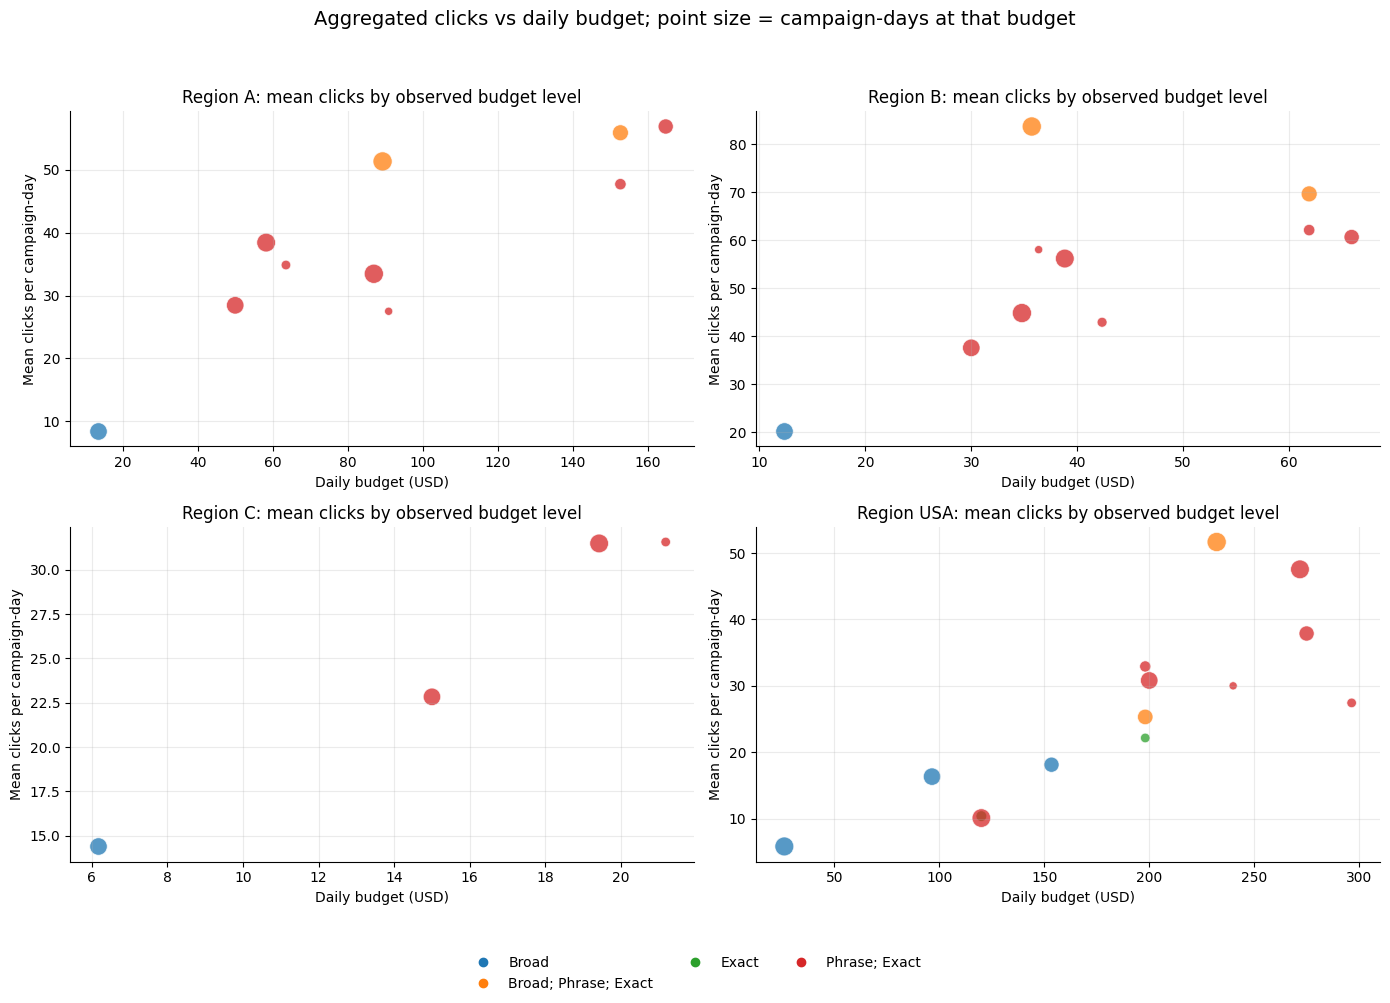

,region,match_types,daily_budget,mean_clicks,median_clicks,total_clicks,campaign_days
0,A,Broad,13.530,8.468,8.000,652,77
1,A,Broad; Phrase; Exact,89.290,51.330,51.000,5749,112
2,A,Broad; Phrase; Exact,152.700,55.889,56.500,3018,54
3,A,Phrase; Exact,50.000,28.449,26.000,2219,78
4,A,Phrase; Exact,58.250,38.422,40.000,3919,102
5,A,Phrase; Exact,63.530,34.857,39.000,244,7
6,A,Phrase; Exact,86.960,33.464,32.000,3748,112
7,A,Phrase; Exact,90.910,27.500,27.500,55,2
8,A,Phrase; Exact,152.700,47.714,45.500,668,14
9,A,Phrase; Exact,164.770,56.886,59.500,2503,44


In [3]:
budget_points = (
    campaign_day
    .groupby(["region", "match_types", "daily_budget"], as_index=False)
    .agg(
        mean_clicks=("clicks", "mean"),
        median_clicks=("clicks", "median"),
        total_clicks=("clicks", "sum"),
        campaign_days=("date", "nunique"),
    )
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.ravel()

for ax, region in zip(axes, regions):
    sub = budget_points[budget_points["region"] == region]
    for match_config in match_configs:
        s = sub[sub["match_types"] == match_config]
        if s.empty:
            continue
        ax.scatter(
            s["daily_budget"],
            s["mean_clicks"],
            s=np.clip(np.sqrt(s["campaign_days"]) * 18, 35, 210),
            alpha=0.75,
            label=match_config,
            color=colors[match_config],
            edgecolors="white",
            linewidths=0.6,
        )
    ax.set_title(f"Region {region}: mean clicks by observed budget level")
    ax.set_xlabel("Daily budget (USD)")
    ax.set_ylabel("Mean clicks per campaign-day")

legend_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=colors[mc], label=mc)
    for mc in match_configs
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Aggregated clicks vs daily budget; point size = campaign-days at that budget", y=0.99, fontsize=14)
fig.tight_layout(rect=(0, 0.08, 1, 0.96))
plt.show()

budget_points.sort_values(["region", "match_types", "daily_budget"]).head(20)

## Does Keyword Count Affect Click Performance?

Join the campaign-day panel to `campaign-summary.csv` by `campaign_version`, then compare keyword inventory size with two campaign-level performance metrics:

- `clicks_per_day`: average daily clicks for that campaign version.
- `clicks_per_100_budget`: average daily clicks normalized by daily budget.

This is descriptive EDA, not a causal estimate. Keyword count is confounded with region, match type, budget, timing, and campaign setup.

In [4]:
keyword_cols = [
    "campaign_version",
    "num_unique_keywords",
    "broad_keyword_count",
    "phrase_keyword_count",
    "exact_keyword_count",
    "num_negative_keywords",
]

campaign_perf = (
    campaign_day
    .merge(campaign_summary[keyword_cols], on="campaign_version", how="left")
    .groupby(
        [
            "campaign_version",
            "region",
            "match_types",
            "daily_budget",
            "num_unique_keywords",
            "broad_keyword_count",
            "phrase_keyword_count",
            "exact_keyword_count",
            "num_negative_keywords",
        ],
        as_index=False,
    )
    .agg(
        start_date=("date", "min"),
        end_date=("date", "max"),
        campaign_days=("date", "nunique"),
        clicks=("clicks", "sum"),
        cost=("cost", "sum"),
        clicks_per_day=("clicks", "mean"),
    )
)

campaign_perf["clicks_per_100_budget"] = campaign_perf["clicks_per_day"] / campaign_perf["daily_budget"] * 100
campaign_perf["cost_per_click"] = campaign_perf["cost"] / campaign_perf["clicks"].replace(0, np.nan)

corr_rows = []
for metric in ["clicks_per_day", "clicks_per_100_budget", "cost_per_click"]:
    corr_rows.append(
        {
            "metric": metric,
            "pearson_corr_with_num_unique_keywords": campaign_perf["num_unique_keywords"].corr(campaign_perf[metric]),
            "n_campaign_versions": campaign_perf[["num_unique_keywords", metric]].dropna().shape[0],
        }
    )

corr_summary = pd.DataFrame(corr_rows)
print("Correlation across campaign versions")
display(corr_summary)

group_corr = []
for match_config, sub in campaign_perf.groupby("match_types"):
    if len(sub) < 3 or sub["num_unique_keywords"].nunique() < 2:
        continue
    group_corr.append(
        {
            "match_types": match_config,
            "n_campaign_versions": len(sub),
            "unique_keyword_counts": sub["num_unique_keywords"].nunique(),
            "corr_keywords_vs_clicks_per_day": sub["num_unique_keywords"].corr(sub["clicks_per_day"]),
            "corr_keywords_vs_clicks_per_100_budget": sub["num_unique_keywords"].corr(sub["clicks_per_100_budget"]),
        }
    )

group_corr = pd.DataFrame(group_corr).sort_values("match_types")
print("\nCorrelation within match configurations with enough variation")
display(group_corr)

campaign_perf.sort_values("clicks_per_day", ascending=False).head(15)[
    [
        "region",
        "match_types",
        "daily_budget",
        "num_unique_keywords",
        "campaign_days",
        "clicks_per_day",
        "clicks_per_100_budget",
        "clicks",
    ]
]

Correlation across campaign versions


,metric,pearson_corr_with_num_unique_keywords,n_campaign_versions
0,clicks_per_day,0.298,47
1,clicks_per_100_budget,0.176,47
2,cost_per_click,-0.197,47



Correlation within match configurations with enough variation


,match_types,n_campaign_versions,unique_keyword_counts,corr_keywords_vs_clicks_per_day,corr_keywords_vs_clicks_per_100_budget
0,Broad,6,2,-0.093,-0.809
1,Broad; Phrase; Exact,6,3,0.660,0.522
2,Exact,3,3,0.646,0.959
3,Phrase; Exact,32,13,-0.230,0.160


,region,match_types,daily_budget,num_unique_keywords,campaign_days,clicks_per_day,clicks_per_100_budget,clicks
33,B,Broad; Phrase; Exact,35.710,97,112,83.643,234.228,9368
34,B,Broad; Phrase; Exact,61.900,97,54,69.611,112.457,3759
36,B,Phrase; Exact,61.900,6,3,66.667,107.701,200
37,B,Phrase; Exact,61.900,15,10,61.700,99.677,617
15,B,Phrase; Exact,65.910,114,45,60.622,91.977,2728
38,B,Phrase; Exact,36.360,15,2,58.000,159.516,116
9,A,Phrase; Exact,164.770,106,44,56.886,34.525,2503
12,B,Phrase; Exact,38.830,114,103,56.146,144.593,5783
28,A,Broad; Phrase; Exact,152.700,102,54,55.889,36.600,3018
35,B,Phrase; Exact,61.900,24,1,52.000,84.006,52


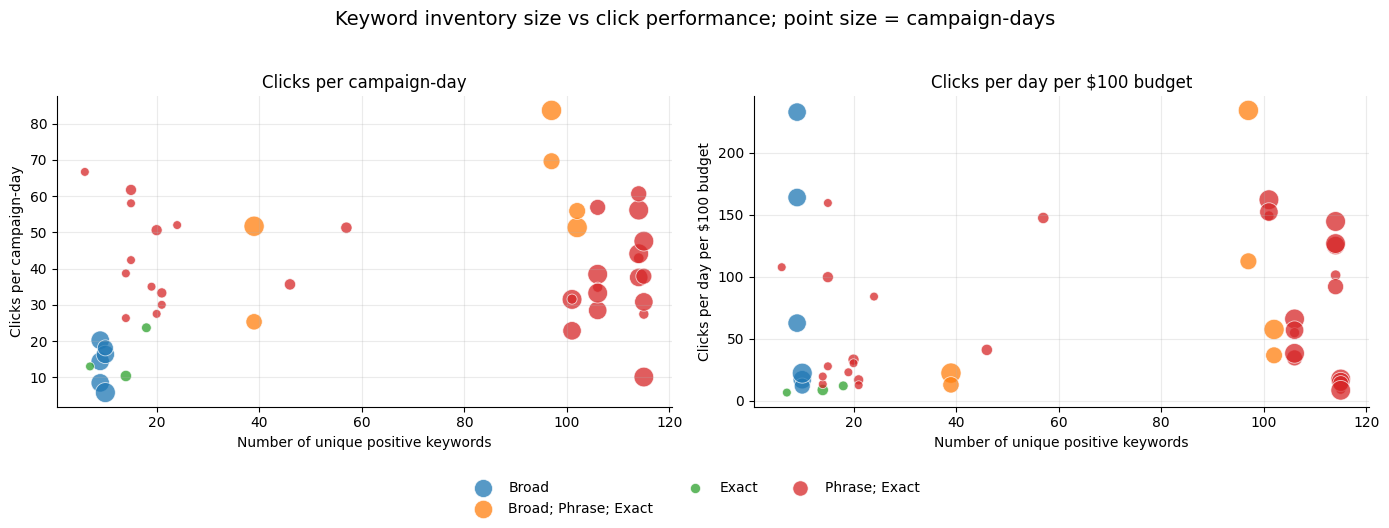

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_col, y_label in [
    (axes[0], "clicks_per_day", "Clicks per campaign-day"),
    (axes[1], "clicks_per_100_budget", "Clicks per day per $100 budget"),
]:
    for match_config in match_configs:
        sub = campaign_perf[campaign_perf["match_types"] == match_config]
        if sub.empty:
            continue
        ax.scatter(
            sub["num_unique_keywords"],
            sub[y_col],
            s=np.clip(np.sqrt(sub["campaign_days"]) * 20, 40, 220),
            alpha=0.75,
            label=match_config,
            color=colors[match_config],
            edgecolors="white",
            linewidths=0.6,
        )
    ax.set_xlabel("Number of unique positive keywords")
    ax.set_ylabel(y_label)
    ax.set_title(y_label)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
fig.suptitle("Keyword inventory size vs click performance; point size = campaign-days", y=1.03, fontsize=14)
fig.tight_layout(rect=(0, 0.12, 1, 1))
plt.show()

## Keyword-Set Performance After Budget Adjustment

This section checks whether keyword-set composition predicts click performance beyond what daily budget explains. Each campaign version maps to a `keyword_set_id` (from `campaign-summary.csv`).

- **Budget residuals**: Within each (region, match_types) stratum, regress daily clicks on daily budget via OLS and take residuals. Positive residuals mean the campaign outperformed its budget level.
- **Semantic features**: BERT embeddings (`all-MiniLM-L6-v2`) capture keyword-set cohesion and relevance to course anchors.
- **Model comparison**: Model A (set dummies) vs Model C (2 semantic features) for RMSE.

In [6]:
KEYWORD_SETS_PATH = DATA_DIR / "campaign-keyword-sets.csv"
EMBEDDINGS_CACHE_PATH = DATA_DIR / "keyword_embeddings.parquet"
EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
MIN_SET_DAYS_FOR_CORR = 7
MIN_SETS_PER_STRATUM = 5

COURSE_ANCHORS = [
    "system thinking",
    "systems thinking",
    "MIT xPRO system thinking",
    "MIT xPRO systems thinking",
]


def parse_kw_list(value) -> set[str]:
    if pd.isna(value) or not str(value).strip():
        return set()
    return {k.strip().lower() for k in str(value).split(";") if k.strip()}


def fit_ols(y: np.ndarray, X: np.ndarray) -> tuple[np.ndarray, np.ndarray, float]:
    """OLS with intercept; returns (coefficients, fitted_values, rmse)."""
    X1 = np.column_stack([np.ones(len(X)), X.astype(float)])
    beta, _, _, _ = np.linalg.lstsq(X1, y.astype(float), rcond=None)
    fitted = X1 @ beta
    rmse = float(np.sqrt(np.mean((y - fitted) ** 2)))
    return beta, fitted, rmse

In [7]:
summary_merge_cols = [
    "campaign_version",
    "keyword_set_id",
    "num_unique_keywords",
    "start_date",
    "end_date",
]

campaign_day_kw = campaign_day.merge(
    campaign_summary[summary_merge_cols],
    on="campaign_version",
    how="left",
)

campaign_perf_kw = (
    campaign_day_kw.groupby(
        [
            "campaign_version",
            "keyword_set_id",
            "region",
            "match_types",
            "daily_budget",
            "num_unique_keywords",
            "start_date",
            "end_date",
        ],
        as_index=False,
    )
    .agg(
        campaign_days=("date", "nunique"),
        clicks=("clicks", "sum"),
        clicks_per_day=("clicks", "mean"),
    )
)
campaign_perf_kw["clicks_per_100_budget"] = (
    campaign_perf_kw["clicks_per_day"] / campaign_perf_kw["daily_budget"] * 100
)

keyword_sets = pd.read_csv(KEYWORD_SETS_PATH)

n_sets = keyword_sets["keyword_set_id"].nunique()
n_versions = campaign_perf_kw["campaign_version"].nunique()
n_keywords_unique = len(
    set().union(*(parse_kw_list(v) for v in keyword_sets["unique_keywords"].dropna()))
)

print("=== Keyword-set audit ===")
print(f"n_keyword_sets: {n_sets}")
print(f"n_campaign_versions (with keyword_set_id): {n_versions}")
print(f"n_unique_positive_keywords (to embed): {n_keywords_unique}")
print("\nCampaign-days per keyword_set_id:")
print(campaign_day_kw.groupby("keyword_set_id")["date"].count().describe().to_string())

exact_cells = (
    campaign_perf_kw.groupby(["region", "match_types", "daily_budget"], as_index=False)
    .agg(n_sets=("keyword_set_id", "nunique"))
)
multi_budget_cells = exact_cells[exact_cells["n_sets"] > 1]
print(f"\n(region, match_types, daily_budget) cells with 2+ keyword sets: {len(multi_budget_cells)}")
if not multi_budget_cells.empty:
    display(multi_budget_cells.sort_values("n_sets", ascending=False).head(15))

=== Keyword-set audit ===
n_keyword_sets: 25
n_campaign_versions (with keyword_set_id): 36
n_unique_positive_keywords (to embed): 158

Campaign-days per keyword_set_id:
count    25.000
mean     88.880
std     115.474
min       1.000
25%       3.000
50%      12.000
75%     166.000
max     335.000

(region, match_types, daily_budget) cells with 2+ keyword sets: 4


,region,match_types,daily_budget,n_sets
6,A,Phrase; Exact,152.700,3
14,B,Phrase; Exact,61.900,3
24,USA,Phrase; Exact,198.100,3
22,USA,Exact,198.100,2


### Semantic keyword-set features

Positive keywords are embedded once (`all-MiniLM-L6-v2`, L2-normalized). Course anchors: *system thinking*, *systems thinking*, *MIT xPRO system thinking*, *MIT xPRO systems thinking* (max cosine per keyword).

| Feature | Meaning |
|---------|---------|
| `embed_cohesion` | Mean pairwise cosine similarity within the set |
| `embed_dispersion` | Mean cosine distance to the set centroid |
| `embed_course_sim_mean` | Mean max anchor similarity |
| `embed_course_sim_p90` | 90th percentile of per-keyword anchor similarity |

In [8]:
from sentence_transformers import SentenceTransformer


def load_or_build_embeddings(keywords: list[str], model_name: str) -> dict[str, np.ndarray]:
    """Return {keyword: embedding} dict, using parquet cache when available."""
    keywords = sorted({k for k in keywords if k})
    emb_map: dict[str, np.ndarray] = {}
    keywords_to_encode = keywords

    if EMBEDDINGS_CACHE_PATH.exists():
        cache = pd.read_parquet(EMBEDDINGS_CACHE_PATH)
        cache = cache[cache["model_name"] == model_name]
        if not cache.empty:
            emb_map = {
                row["keyword"]: np.asarray(row["embedding"], dtype=float)
                for _, row in cache.iterrows()
            }
            keywords_to_encode = [k for k in keywords if k not in emb_map]
            if not keywords_to_encode:
                return emb_map

    model = SentenceTransformer(model_name)
    new_vecs = model.encode(
        keywords_to_encode,
        normalize_embeddings=True,
        show_progress_bar=len(keywords_to_encode) > 50,
    )
    for kw, vec in zip(keywords_to_encode, new_vecs):
        emb_map[kw] = np.asarray(vec, dtype=float)

    rows = [
        {"keyword": k, "model_name": model_name, "embedding": emb_map[k].tolist()}
        for k in sorted(emb_map)
    ]
    pd.DataFrame(rows).to_parquet(EMBEDDINGS_CACHE_PATH, index=False)
    return emb_map


def pairwise_mean_cosine(vectors: list[np.ndarray]) -> float:
    n = len(vectors)
    if n < 2:
        return np.nan
    sims = [
        float(np.dot(vectors[i], vectors[j]))
        for i in range(n) for j in range(i + 1, n)
    ]
    return float(np.mean(sims))


def mean_dispersion_to_centroid(vectors: list[np.ndarray]) -> float:
    if len(vectors) < 2:
        return np.nan
    centroid = np.mean(vectors, axis=0)
    centroid = centroid / np.linalg.norm(centroid)
    return float(np.mean([1.0 - float(np.dot(v, centroid)) for v in vectors]))

In [9]:
all_keywords = sorted(
    set().union(*(parse_kw_list(v) for v in keyword_sets["unique_keywords"].dropna()))
)
anchor_keywords = [a.lower() for a in COURSE_ANCHORS]
emb_map = load_or_build_embeddings(all_keywords + anchor_keywords, EMBED_MODEL_NAME)
anchor_matrix = np.stack([emb_map[a] for a in anchor_keywords])

feature_rows = []
for _, row in keyword_sets.iterrows():
    kws = sorted(parse_kw_list(row["unique_keywords"]))
    vectors = [emb_map[k] for k in kws if k in emb_map]
    if not vectors:
        continue
    anchor_sims = np.array([np.max(anchor_matrix @ v) for v in vectors])
    feature_rows.append({
        "keyword_set_id": row["keyword_set_id"],
        "n_positive": len(kws),
        "embed_cohesion": pairwise_mean_cosine(vectors),
        "embed_dispersion": mean_dispersion_to_centroid(vectors),
        "embed_course_sim_mean": float(np.mean(anchor_sims)),
        "embed_course_sim_p90": float(np.percentile(anchor_sims, 90)),
    })

keyword_set_features = pd.DataFrame(feature_rows)
feature_cols = ["embed_cohesion", "embed_dispersion", "embed_course_sim_mean", "embed_course_sim_p90"]

print(f"n_keywords_embedded (cache/model={EMBED_MODEL_NAME}): {len(all_keywords)}")
print(f"n_sets with semantic features: {len(keyword_set_features)}")
print("\nFeature collinearity (Spearman):")
display(keyword_set_features[feature_cols].corr(method="spearman"))

campaign_perf_kw = campaign_perf_kw.merge(keyword_set_features, on="keyword_set_id", how="left")
keyword_set_features.sort_values("embed_course_sim_mean", ascending=False).head(15)

n_keywords_embedded (cache/model=sentence-transformers/all-MiniLM-L6-v2): 158
n_sets with semantic features: 25

Feature collinearity (Spearman):


,embed_cohesion,embed_dispersion,embed_course_sim_mean,embed_course_sim_p90
embed_cohesion,1.000,-0.975,0.952,0.703
embed_dispersion,-0.975,1.000,-0.939,-0.733
embed_course_sim_mean,0.952,-0.939,1.000,0.828
embed_course_sim_p90,0.703,-0.733,0.828,1.000


,keyword_set_id,n_positive,embed_cohesion,embed_dispersion,embed_course_sim_mean,embed_course_sim_p90
23,ks_0024,14,0.576,0.221,0.729,0.898
22,ks_0023,14,0.557,0.233,0.714,0.898
20,ks_0021,18,0.544,0.245,0.672,0.901
24,ks_0025,21,0.508,0.271,0.663,0.890
18,ks_0019,15,0.510,0.263,0.660,0.897
13,ks_0014,15,0.571,0.226,0.660,0.885
19,ks_0020,39,0.524,0.268,0.658,0.899
14,ks_0015,20,0.503,0.273,0.648,0.891
10,ks_0011,14,0.494,0.272,0.642,0.902
21,ks_0022,7,0.404,0.300,0.598,0.909


In [10]:
residual_parts = []
for (region, match_types), sub in campaign_day_kw.groupby(["region", "match_types"]):
    if len(sub) < 3:
        continue
    x = sub["daily_budget"].to_numpy().reshape(-1, 1)
    y = sub["clicks"].to_numpy()
    _, fitted, _ = fit_ols(y, x)
    part = sub[["keyword_set_id", "clicks", "daily_budget"]].copy()
    part["residual"] = y - fitted
    part["region"] = region
    part["match_types"] = match_types
    residual_parts.append(part)

residual_days = pd.concat(residual_parts, ignore_index=True)
set_residuals = (
    residual_days.groupby("keyword_set_id", as_index=False)
    .agg(mean_budget_residual=("residual", "mean"), campaign_days=("residual", "count"))
)
set_residuals = set_residuals.merge(
    campaign_perf_kw.groupby("keyword_set_id", as_index=False).agg(
        clicks_per_100_budget=("clicks_per_100_budget", "mean"),
        region=("region", "first"),
        match_types=("match_types", "first"),
    ),
    on="keyword_set_id",
)
set_performance = set_residuals.merge(keyword_set_features, on="keyword_set_id", how="left")
set_performance_corr = set_performance[
    set_performance["campaign_days"] >= MIN_SET_DAYS_FOR_CORR
].copy()

print(f"n_sets in correlation analysis (>={MIN_SET_DAYS_FOR_CORR} days): {len(set_performance_corr)}")

day_df = campaign_day_kw.dropna(subset=["keyword_set_id"]).copy()

X_a = pd.get_dummies(day_df[["daily_budget", "keyword_set_id", "region", "match_types"]], drop_first=True)
_, _, rmse_a = fit_ols(day_df["clicks"].to_numpy(), X_a.to_numpy())
print(f"Model A RMSE (clicks ~ budget + set + region + match_types): {rmse_a:,.3f}")

sem = day_df.merge(keyword_set_features, on="keyword_set_id", how="left")
for col in ["embed_course_sim_mean", "embed_dispersion"]:
    sem[f"z_{col}"] = (sem[col] - sem[col].mean()) / sem[col].std(ddof=0)
X_c = pd.get_dummies(sem[["daily_budget", "region", "match_types"]], drop_first=True)
X_c[["z_embed_course_sim_mean", "z_embed_dispersion"]] = sem[["z_embed_course_sim_mean", "z_embed_dispersion"]]
_, _, rmse_c = fit_ols(sem["clicks"].to_numpy(), X_c.to_numpy())
print(f"Model C RMSE (2 semantic + budget + segment): {rmse_c:,.3f}")

n_sets in correlation analysis (>=7 days): 11
Model A RMSE (clicks ~ budget + set + region + match_types): 13.321
Model C RMSE (2 semantic + budget + segment): 14.567


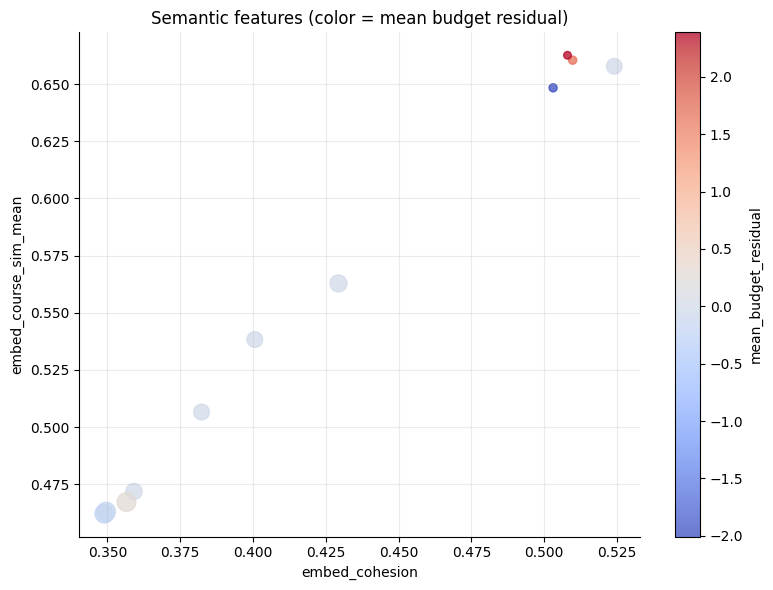

Saved figures\keyword-set-semantic-vs-residuals.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_sub = set_performance_corr.dropna(subset=["embed_cohesion", "embed_course_sim_mean"])
sizes = np.clip(np.sqrt(plot_sub["campaign_days"]) * 10, 30, 300)
sc = ax.scatter(
    plot_sub["embed_cohesion"],
    plot_sub["embed_course_sim_mean"],
    s=sizes,
    alpha=0.75,
    c=plot_sub["mean_budget_residual"],
    cmap="coolwarm",
)
ax.set_xlabel("embed_cohesion")
ax.set_ylabel("embed_course_sim_mean")
ax.set_title("Semantic features (color = mean budget residual)")
plt.colorbar(sc, ax=ax, label="mean_budget_residual")
fig.tight_layout()
fig_path = Path("figures/keyword-set-semantic-vs-residuals.png")
fig_path.parent.mkdir(exist_ok=True)
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {fig_path}")

In [12]:
corr_targets = ["mean_budget_residual", "clicks_per_100_budget"]
corr_rows = []
for feat in feature_cols:
    for target in corr_targets:
        sub = set_performance_corr[[feat, target]].dropna()
        rho = sub[feat].corr(sub[target], method="spearman") if len(sub) >= 4 else np.nan
        corr_rows.append({"feature": feat, "target": target, "spearman_rho": rho, "n_sets": len(sub)})

corr_table = pd.DataFrame(corr_rows)
print("Set-level Spearman (sets with >=7 campaign-days):")
display(corr_table.pivot(index="feature", columns="target", values="spearman_rho"))

print("\nWithin-stratum Spearman (requires >=5 sets):")
for (region, match_types), sub in set_performance_corr.groupby(["region", "match_types"]):
    if sub["keyword_set_id"].nunique() < MIN_SETS_PER_STRATUM:
        print(f"  {region} / {match_types}: insufficient sets ({sub['keyword_set_id'].nunique()})")
        continue
    print(f"  {region} / {match_types} (n_sets={sub['keyword_set_id'].nunique()})")
    for feat in feature_cols:
        rho = sub[feat].corr(sub["mean_budget_residual"], method="spearman")
        print(f"    {feat} vs mean_budget_residual: {rho:,.3f}")

multi_set_versions = (
    campaign_perf_kw.groupby(["region", "match_types", "daily_budget"])
    .filter(lambda g: g["keyword_set_id"].nunique() > 1)
)
exact_compare_cols = [
    "region", "match_types", "daily_budget", "keyword_set_id",
    "clicks_per_day", "clicks_per_100_budget", "campaign_days",
    "start_date", "end_date", "embed_course_sim_mean", "embed_dispersion", "n_positive",
]
if multi_set_versions.empty:
    print("\nNo exact (region, match_types, daily_budget) cells with 2+ keyword sets.")
else:
    print("\nExact same-budget comparisons:")
    display(
        multi_set_versions[exact_compare_cols].sort_values(
            ["region", "match_types", "daily_budget", "clicks_per_day"],
            ascending=[True, True, True, False],
        )
    )

Set-level Spearman (sets with >=7 campaign-days):


target,clicks_per_100_budget,mean_budget_residual
feature,,
embed_cohesion,-0.255,0.518
embed_course_sim_mean,-0.273,0.573
embed_course_sim_p90,-0.191,0.455
embed_dispersion,0.218,-0.536



Within-stratum Spearman (requires >=5 sets):
  A / Broad; Phrase; Exact: insufficient sets (1)
  A / Phrase; Exact: insufficient sets (2)
  B / Broad; Phrase; Exact: insufficient sets (1)
  B / Phrase; Exact: insufficient sets (2)
  C / Phrase; Exact: insufficient sets (1)
  USA / Broad: insufficient sets (1)
  USA / Broad; Phrase; Exact: insufficient sets (1)
  USA / Phrase; Exact: insufficient sets (2)

Exact same-budget comparisons:


,region,match_types,daily_budget,keyword_set_id,clicks_per_day,clicks_per_100_budget,campaign_days,start_date,end_date,embed_course_sim_mean,embed_dispersion,n_positive
23,A,Phrase; Exact,152.700,ks_0015,50.600,33.137,10,2026-05-02,2026-05-12,0.648,0.273,20
22,A,Phrase; Exact,152.700,ks_0014,42.333,27.723,3,2026-04-29,2026-05-02,0.660,0.226,15
21,A,Phrase; Exact,152.700,ks_0013,35.000,22.921,1,2026-04-06,2026-04-22,0.549,0.334,19
27,B,Phrase; Exact,61.900,ks_0018,66.667,107.701,3,2026-04-29,2026-05-02,0.584,0.226,6
28,B,Phrase; Exact,61.900,ks_0019,61.700,99.677,10,2026-05-02,2026-05-12,0.660,0.263,15
26,B,Phrase; Exact,61.900,ks_0017,52.000,84.006,1,2026-04-06,2026-04-22,0.443,0.409,24
31,USA,Exact,198.100,ks_0021,23.667,11.947,6,2026-03-31,2026-04-06,0.672,0.245,18
32,USA,Exact,198.100,ks_0022,13.000,6.562,1,2026-04-06,2026-04-22,0.598,0.300,7
34,USA,Phrase; Exact,198.100,ks_0024,38.667,19.519,3,2026-05-02,2026-05-05,0.729,0.221,14
35,USA,Phrase; Exact,198.100,ks_0025,33.286,16.802,7,2026-05-05,2026-05-12,0.663,0.271,21


## Top-20 Keyword Overlap Across Regions and Match Types

For this section, use the keyword-day panel and restrict it to the same date range covered by the campaign-day panel. Within each `(region, match_type)` group, rank keywords by total clicks and take the top 20. The overlap tables report how many keyword strings are shared between each pair of top-20 lists.

In [13]:
date_min = campaign_day["date"].min()
date_max = campaign_day["date"].max()
kw_window = kw_day[(kw_day["date"] >= date_min) & (kw_day["date"] <= date_max)].copy()

keyword_clicks = (
    kw_window
    .groupby(["region", "match_type", "keyword"], as_index=False)
    .agg(
        clicks=("clicks", "sum"),
        cost=("cost", "sum"),
        active_days=("date", "nunique"),
    )
)

top20 = (
    keyword_clicks
    .sort_values(["region", "match_type", "clicks", "active_days", "keyword"], ascending=[True, True, False, False, True])
    .groupby(["region", "match_type"], as_index=False)
    .head(20)
    .copy()
)
top20["rank"] = top20.groupby(["region", "match_type"])["clicks"].rank(method="first", ascending=False).astype(int)

print(f"Keyword-day rows in campaign-day date window: {len(kw_window):,}")
print(f"Top-20 groups found: {top20.groupby(['region', 'match_type']).ngroups}")

top20.head(30)

top_sets = {
    key: set(group["keyword"])
    for key, group in top20.groupby(["region", "match_type"])
}

Keyword-day rows in campaign-day date window: 36,572
Top-20 groups found: 12


,A / Broad,A / Exact,A / Phrase,B / Broad,B / Exact,B / Phrase,C / Broad,C / Exact,C / Phrase,USA / Broad,USA / Exact,USA / Phrase
A / Broad,20,4,2,9,5,1,7,3,1,8,5,2
A / Exact,4,20,6,4,14,5,5,11,4,5,14,5
A / Phrase,2,6,20,2,6,15,1,7,13,3,6,15
B / Broad,9,4,2,20,5,1,8,3,1,10,5,2
B / Exact,5,14,6,5,20,6,5,13,6,5,15,4
B / Phrase,1,5,15,1,6,20,1,5,15,2,4,14
C / Broad,7,5,1,8,5,1,9,4,1,9,5,1
C / Exact,3,11,7,3,13,5,4,20,5,4,13,5
C / Phrase,1,4,13,1,6,15,1,5,20,2,5,14
USA / Broad,8,5,3,10,5,2,9,4,2,20,6,3


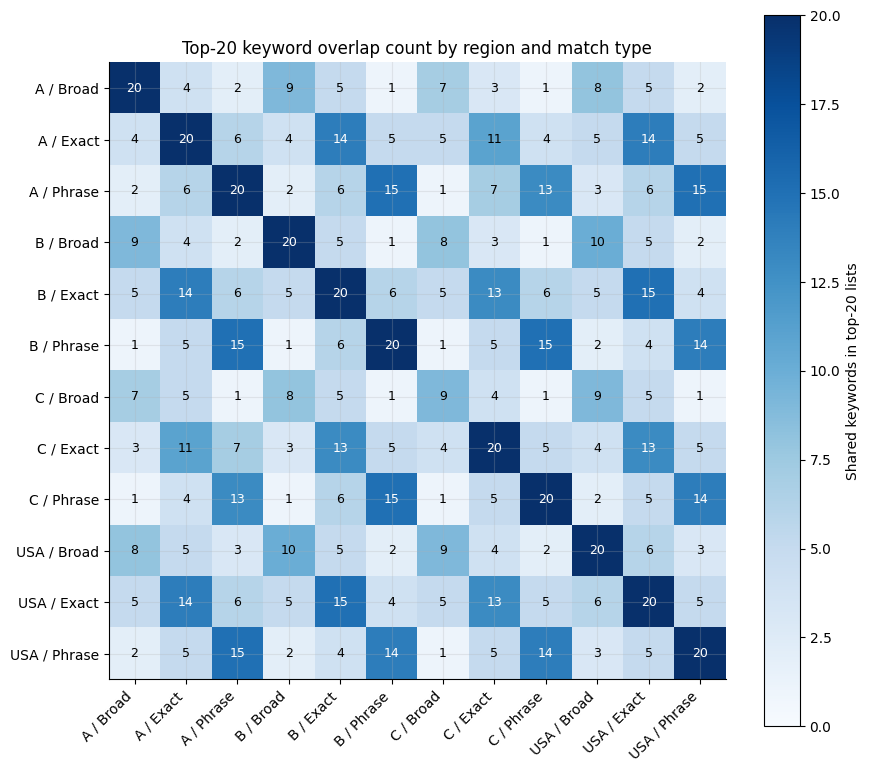

In [14]:
labels = [f"{k[0]} / {k[1]}" for k in sorted(top_sets)]
overlap_matrix = pd.DataFrame(index=labels, columns=labels, dtype=float)

for key_a in sorted(top_sets):
    for key_b in sorted(top_sets):
        overlap_matrix.loc[f"{key_a[0]} / {key_a[1]}", f"{key_b[0]} / {key_b[1]}"] = len(top_sets[key_a] & top_sets[key_b])

display(overlap_matrix.astype(int))

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(overlap_matrix.values.astype(float), cmap="Blues", vmin=0, vmax=20)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.set_title("Top-20 keyword overlap count by region and match type")

for i in range(overlap_matrix.shape[0]):
    for j in range(overlap_matrix.shape[1]):
        value = int(overlap_matrix.iloc[i, j])
        ax.text(j, i, value, ha="center", va="center", color="black" if value < 12 else "white", fontsize=9)

fig.colorbar(im, ax=ax, label="Shared keywords in top-20 lists")
fig.tight_layout()
plt.show()

---

## Feasibility Analysis 1: Budget-Response Curve Viability

For each `(region, match_types)` segment with â‰¥3 distinct budget levels, fit:
- **Linear OLS**: `clicks ~ a + b * budget`
- **Power law**: `clicks ~ a * budget^b` (captures diminishing or accelerating returns)

Report RÂ² and RMSE for each segment. Segments with RÂ² < 0.3 will need fallback treatment in the optimization.

Distinct budget levels per segment:
region  match_types         
A       Phrase; Exact           7
B       Phrase; Exact           7
USA     Phrase; Exact           7
        Broad                   3
C       Phrase; Exact           3
USA     Broad; Phrase; Exact    2
A       Broad; Phrase; Exact    2
B       Broad; Phrase; Exact    2
USA     Exact                   2
A       Broad                   1
B       Broad                   1
C       Broad                   1

Segments usable for curve fitting (â‰¥3 budget levels): 5


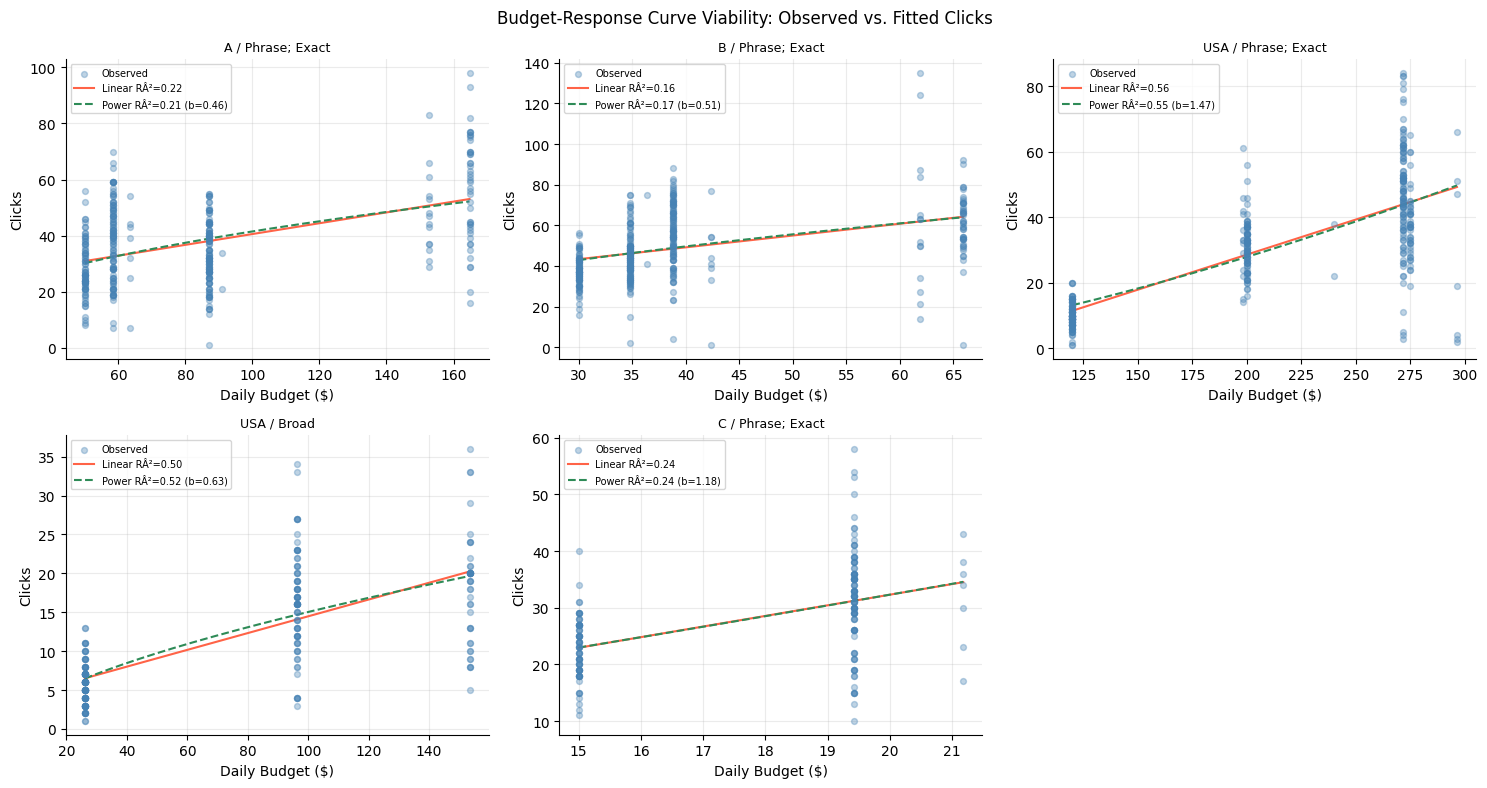


Model Fit Summary:
                     n_days  n_budget_levels  budget_min  budget_max  r2_linear  rmse_linear  r2_power  rmse_power  power_b
segment                                                                                                                    
A / Phrase; Exact       359                7      50.000     164.770      0.222       13.660     0.207      13.790    0.459
B / Phrase; Exact       362                7      30.000      65.910      0.161       15.310     0.171      15.210    0.509
USA / Phrase; Exact     346                7     120.000     296.470      0.563       12.190     0.552      12.350    1.469
USA / Broad             226                3      26.090     153.420      0.500        5.360     0.521       5.250    0.626
C / Phrase; Exact       187                3      15.000      21.180      0.242        7.480     0.242       7.490    1.184


In [15]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

# Segments with â‰¥3 distinct budget levels
seg_budget_counts = (
    campaign_day
    .groupby(["region", "match_types"])["daily_budget"]
    .nunique()
    .sort_values(ascending=False)
)
print("Distinct budget levels per segment:")
print(seg_budget_counts.to_string())

rich_segs = seg_budget_counts[seg_budget_counts >= 3].index.tolist()
print(f"\nSegments usable for curve fitting (â‰¥3 budget levels): {len(rich_segs)}")


def power_law(x, a, b):
    return a * np.power(x, b)


response_results = []

n_segs = len(rich_segs)
fig_cols = 3
fig_rows = -(-n_segs // fig_cols)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 4 * fig_rows))
axes = axes.ravel()

for ax_i, (region, mt) in enumerate(rich_segs):
    sub = campaign_day[
        (campaign_day["region"] == region) & (campaign_day["match_types"] == mt)
    ].copy()
    X = sub["daily_budget"].values
    y = sub["clicks"].values

    # Linear OLS
    coeffs = np.polyfit(X, y, 1)
    y_pred_lin = np.polyval(coeffs, X)
    r2_lin = r2_score(y, y_pred_lin)
    rmse_lin = float(np.sqrt(mean_squared_error(y, y_pred_lin)))

    # Power law
    try:
        popt, _ = curve_fit(power_law, X, y, p0=[1.0, 0.8], bounds=([0, 0], [np.inf, 3]), maxfev=10000)
        y_pred_pow = power_law(X, *popt)
        r2_pow = r2_score(y, y_pred_pow)
        rmse_pow = float(np.sqrt(mean_squared_error(y, y_pred_pow)))
        pow_a, pow_b = popt
    except Exception:
        r2_pow, rmse_pow, pow_a, pow_b = np.nan, np.nan, np.nan, np.nan
        y_pred_pow = None

    response_results.append({
        "segment": f"{region} / {mt}",
        "region": region,
        "match_types": mt,
        "n_days": len(sub),
        "n_budget_levels": int(sub["daily_budget"].nunique()),
        "budget_min": X.min(),
        "budget_max": X.max(),
        "r2_linear": round(r2_lin, 3),
        "rmse_linear": round(rmse_lin, 2),
        "r2_power": round(r2_pow, 3) if not np.isnan(r2_pow) else np.nan,
        "rmse_power": round(rmse_pow, 2) if not np.isnan(rmse_pow) else np.nan,
        "power_a": round(pow_a, 4) if not np.isnan(pow_a) else np.nan,
        "power_b": round(pow_b, 4) if not np.isnan(pow_b) else np.nan,
    })

    ax = axes[ax_i]
    ax.scatter(X, y, alpha=0.35, s=18, color="steelblue", label="Observed", zorder=3)
    x_line = np.linspace(X.min(), X.max(), 300)
    ax.plot(x_line, np.polyval(coeffs, x_line), color="tomato", lw=1.5,
            label=f"Linear RÂ²={r2_lin:.2f}")
    if y_pred_pow is not None:
        ax.plot(x_line, power_law(x_line, *popt), color="seagreen", lw=1.5, ls="--",
                label=f"Power RÂ²={r2_pow:.2f} (b={pow_b:.2f})")
    ax.set_title(f"{region} / {mt}", fontsize=9)
    ax.set_xlabel("Daily Budget ($)")
    ax.set_ylabel("Clicks")
    ax.legend(fontsize=7)

for j in range(ax_i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Budget-Response Curve Viability: Observed vs. Fitted Clicks", fontsize=12)
plt.tight_layout()
plt.savefig("figures/budget-response-viability.png", dpi=150, bbox_inches="tight")
plt.show()

response_df = pd.DataFrame(response_results).set_index("segment")
print("\nModel Fit Summary:")
print(response_df[["n_days", "n_budget_levels", "budget_min", "budget_max",
                    "r2_linear", "rmse_linear", "r2_power", "rmse_power",
                    "power_b"]].to_string())

---

## Feasibility Analysis 2: Temporal Stability

Plot click rate (`clicks / daily_budget`) over time for each data-rich segment. A stable click rate is required for historical data to remain predictive. Look for:
- Level shifts (may indicate keyword set changes or seasonality)
- Monotonic trends (secular CTR decline)
- Regime breaks around campaign-version transitions

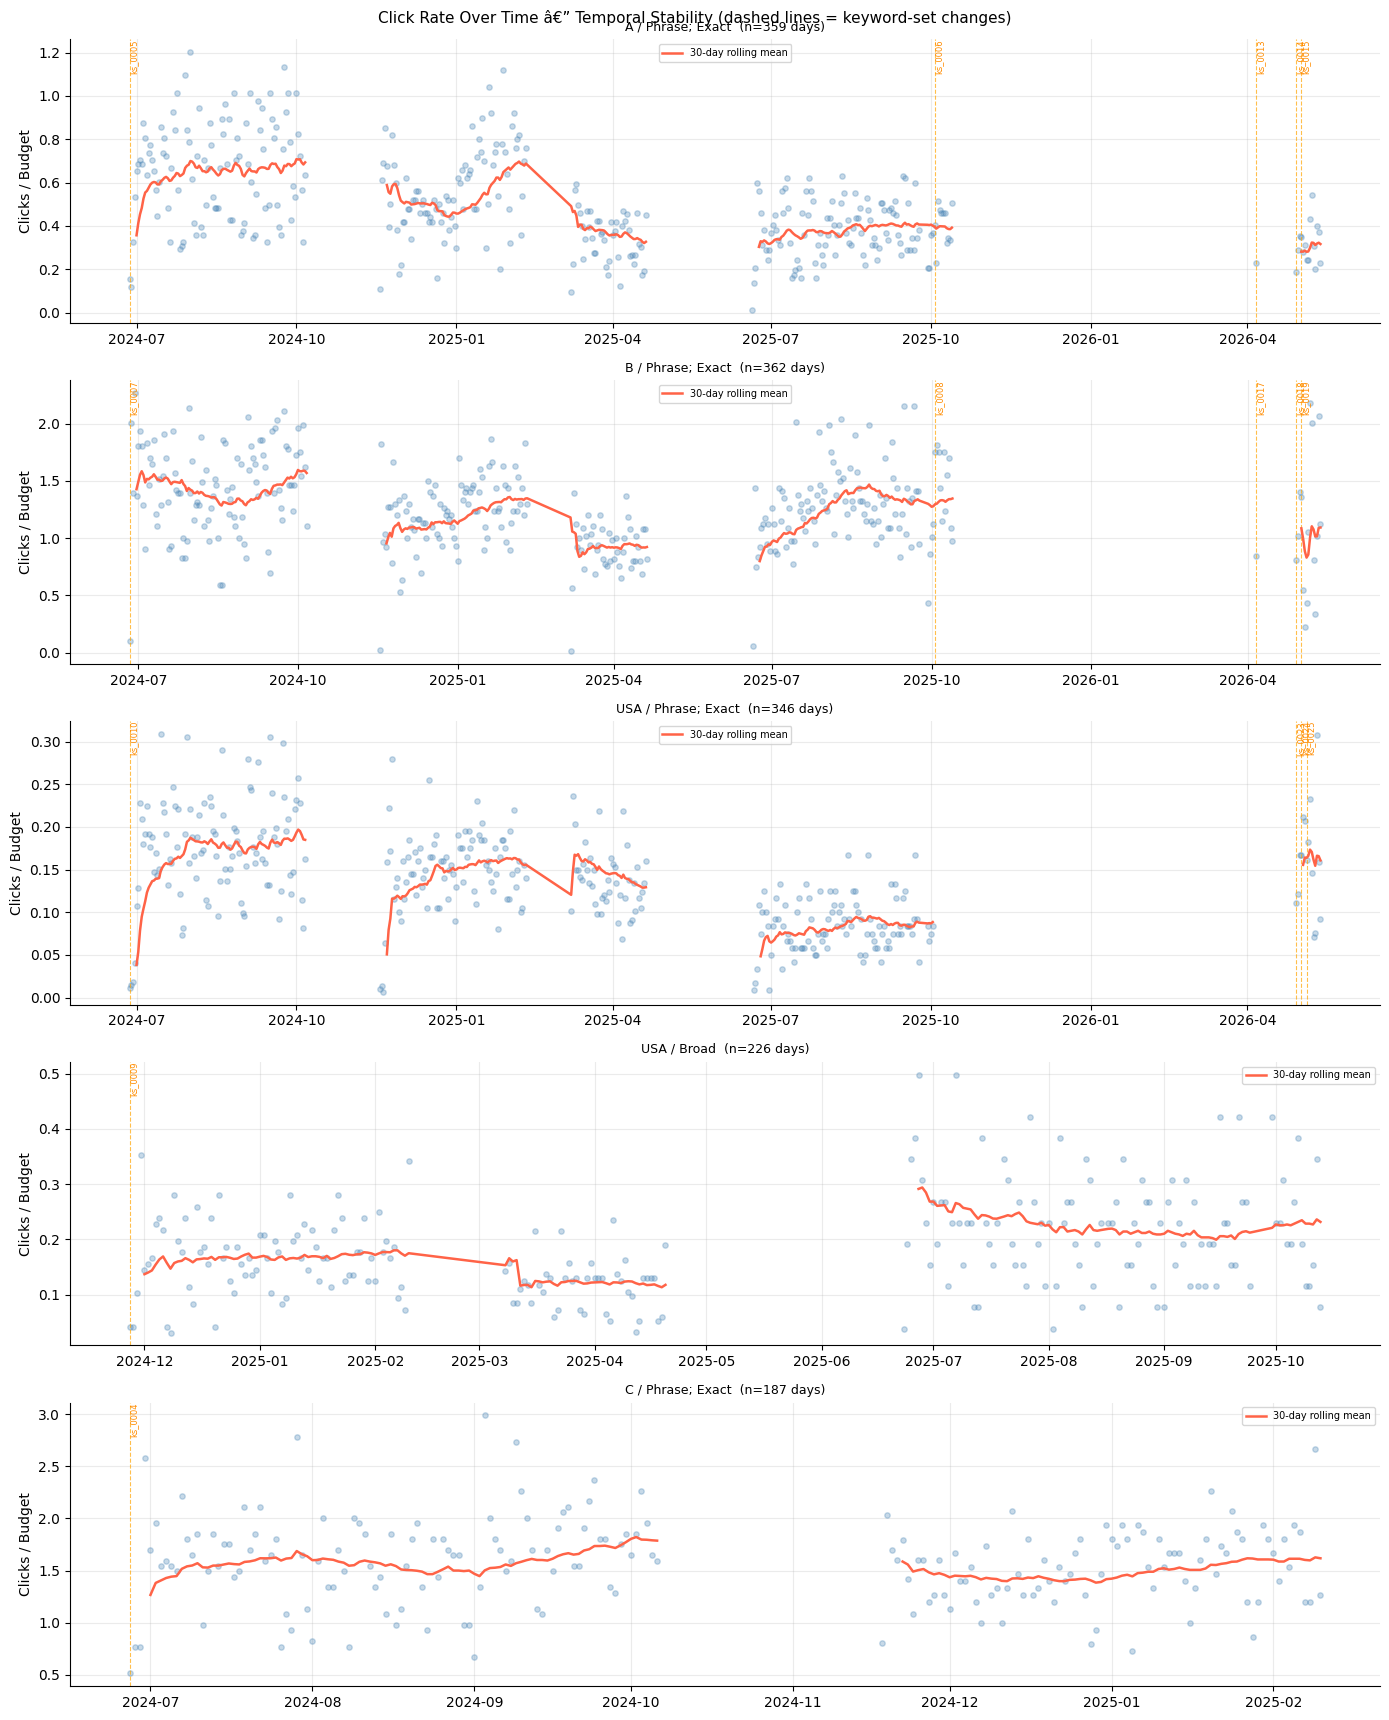

In [16]:
# Join campaign_version â†’ keyword_set_id so we can annotate version transitions
cv_to_ks = campaign_summary.set_index("campaign_version")["keyword_set_id"].to_dict()
campaign_day_ts = campaign_day.copy()
campaign_day_ts["keyword_set_id"] = campaign_day_ts["campaign_version"].map(cv_to_ks)
campaign_day_ts["click_rate"] = campaign_day_ts["clicks"] / campaign_day_ts["daily_budget"]

fig, axes = plt.subplots(len(rich_segs), 1, figsize=(14, 3.5 * len(rich_segs)), sharex=False)
if len(rich_segs) == 1:
    axes = [axes]

for ax, (region, mt) in zip(axes, rich_segs):
    sub = campaign_day_ts[
        (campaign_day_ts["region"] == region) & (campaign_day_ts["match_types"] == mt)
    ].copy().sort_values("date")

    ax.scatter(sub["date"], sub["click_rate"], alpha=0.3, s=15, color="steelblue", zorder=2)

    # 30-day rolling mean
    roll = sub.set_index("date")["click_rate"].rolling("30D", min_periods=5).mean()
    ax.plot(roll.index, roll.values, color="tomato", lw=1.8, label="30-day rolling mean", zorder=3)

    # Mark keyword-set / campaign-version transitions
    transitions = (
        sub.groupby("keyword_set_id")["date"].min()
        .sort_values()
        .reset_index()
    )
    for _, row in transitions.iterrows():
        ax.axvline(row["date"], color="orange", lw=0.8, ls="--", alpha=0.7)
        ax.text(row["date"], ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1,
                row["keyword_set_id"], fontsize=6, rotation=90, va="top", color="darkorange")

    ax.set_title(f"{region} / {mt}  (n={len(sub)} days)", fontsize=9)
    ax.set_ylabel("Clicks / Budget")
    ax.legend(fontsize=7)

fig.suptitle("Click Rate Over Time â€” Temporal Stability (dashed lines = keyword-set changes)", fontsize=11)
plt.tight_layout()
plt.savefig("figures/temporal-stability.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Feasibility Analysis 3: Keyword Set Stability and Overlap

For each segment that has 2+ distinct keyword sets in its history, compute:
- Which keyword sets were used and for how long
- Jaccard overlap between pairs of keyword sets (intersection / union of unique keyword lists)
- Top-20 keyword intersection across versions

High overlap (Jaccard > 0.5) means fixing a keyword set is safe. Low overlap means keyword changes were material and the historical choice matters.

In [17]:
KEYWORD_SETS_PATH = DATA_DIR / "campaign-keyword-sets.csv"
kw_sets_df = pd.read_csv(KEYWORD_SETS_PATH)


def parse_kw_list(s):
    if pd.isna(s) or str(s).strip() == "":
        return set()
    return {k.strip().lower() for k in str(s).split(";") if k.strip()}


# Build keyword_set_id â†’ set of unique positive keywords
ks_kw_map = {
    row["keyword_set_id"]: parse_kw_list(row["unique_keywords"])
    for _, row in kw_sets_df.iterrows()
}

# Get (region, match_types) â†’ list of keyword_set_ids used, with day counts
seg_ks = (
    campaign_day_ts.groupby(["region", "match_types", "keyword_set_id"])
    .size()
    .reset_index(name="n_days")
    .sort_values(["region", "match_types", "n_days"], ascending=[True, True, False])
)

# Focus on segments with â‰¥2 keyword sets
seg_ks_counts = seg_ks.groupby(["region", "match_types"])["keyword_set_id"].nunique()
multi_ks_segs = seg_ks_counts[seg_ks_counts >= 2].index.tolist()
print(f"Segments with â‰¥2 keyword sets: {len(multi_ks_segs)}")
for s in multi_ks_segs:
    print(f"  {s}")

# Pairwise Jaccard for each such segment
stability_rows = []

for region, mt in multi_ks_segs:
    seg_data = seg_ks[(seg_ks["region"] == region) & (seg_ks["match_types"] == mt)]
    ks_ids = seg_data["keyword_set_id"].tolist()
    ks_days = dict(zip(seg_data["keyword_set_id"], seg_data["n_days"]))

    for ks_a, ks_b in combinations(ks_ids, 2):
        kw_a = ks_kw_map.get(ks_a, set())
        kw_b = ks_kw_map.get(ks_b, set())
        if not kw_a and not kw_b:
            continue
        jaccard = len(kw_a & kw_b) / len(kw_a | kw_b) if (kw_a | kw_b) else np.nan
        stability_rows.append({
            "segment": f"{region} / {mt}",
            "ks_a": ks_a,
            "ks_b": ks_b,
            "days_a": ks_days.get(ks_a, 0),
            "days_b": ks_days.get(ks_b, 0),
            "kw_count_a": len(kw_a),
            "kw_count_b": len(kw_b),
            "intersection": len(kw_a & kw_b),
            "union": len(kw_a | kw_b),
            "jaccard": round(jaccard, 3),
        })

stability_df = pd.DataFrame(stability_rows)
print("\nPairwise Jaccard similarity between keyword sets per segment:")
print(stability_df[["segment", "ks_a", "ks_b", "kw_count_a", "kw_count_b",
                     "intersection", "union", "jaccard", "days_a", "days_b"]].to_string(index=False))

# Summary: median Jaccard per segment
print("\nMedian Jaccard per segment (1.0 = identical keyword lists):")
print(stability_df.groupby("segment")["jaccard"].median().sort_values().to_string())

Segments with â‰¥2 keyword sets: 4
  ('A', 'Phrase; Exact')
  ('B', 'Phrase; Exact')
  ('USA', 'Exact')
  ('USA', 'Phrase; Exact')

Pairwise Jaccard similarity between keyword sets per segment:
            segment    ks_a    ks_b  kw_count_a  kw_count_b  intersection  union  jaccard  days_a  days_b
  A / Phrase; Exact ks_0005 ks_0015         106          20            12    114    0.105     332      12
  A / Phrase; Exact ks_0005 ks_0006         106          46            46    106    0.434     332      11
  A / Phrase; Exact ks_0005 ks_0014         106          15             9    112    0.080     332       3
  A / Phrase; Exact ks_0005 ks_0013         106          19            17    108    0.157     332       1
  A / Phrase; Exact ks_0015 ks_0006          20          46            11     55    0.200      12      11
  A / Phrase; Exact ks_0015 ks_0014          20          15            13     22    0.591      12       3
  A / Phrase; Exact ks_0015 ks_0013          20          19     

In [18]:
# For each segment with multiple keyword sets, show the top-20 overlap across versions
# Top-K intersection: keywords that appear in the top-K of every version

TOP_K = 20

print(f"\nTop-{TOP_K} keyword intersection across keyword set versions (per segment):\n")
for region, mt in multi_ks_segs:
    seg_data = seg_ks[(seg_ks["region"] == region) & (seg_ks["match_types"] == mt)]
    ks_ids = seg_data["keyword_set_id"].tolist()

    # Top-K by click volume from kw_day (aligned to campaign_day date window)
    kw_sub = kw_day[
        (kw_day["region"] == region) &
        (kw_day["match_type"].str.lower().isin([t.strip().lower() for t in mt.split(";")])) &
        (kw_day["date"] >= campaign_day["date"].min()) &
        (kw_day["date"] <= campaign_day["date"].max())
    ]
    
    # Assign keyword_set_id by matching campaign_day date â†’ keyword_set_id
    date_ks = campaign_day_ts[
        (campaign_day_ts["region"] == region) & (campaign_day_ts["match_types"] == mt)
    ][["date", "keyword_set_id"]].drop_duplicates()
    kw_sub = kw_sub.merge(date_ks, on="date", how="inner")

    top_per_ks = {}
    for ks in ks_ids:
        sub_ks = kw_sub[kw_sub["keyword_set_id"] == ks]
        if sub_ks.empty:
            continue
        top = (sub_ks.groupby("keyword")["clicks"].sum()
               .sort_values(ascending=False).head(TOP_K).index.tolist())
        top_per_ks[ks] = set(top)

    if len(top_per_ks) >= 2:
        common = set.intersection(*top_per_ks.values())
        any_top = set.union(*top_per_ks.values())
        print(f"{region} / {mt}  ({len(ks_ids)} keyword sets, {len(common)}/{TOP_K} shared in top-{TOP_K})")
        print(f"  Shared keywords: {sorted(common)}")
        print()


Top-20 keyword intersection across keyword set versions (per segment):

A / Phrase; Exact  (5 keyword sets, 2/20 shared in top-20)
  Shared keywords: ['mit systems thinking', 'what is system thinking']

B / Phrase; Exact  (5 keyword sets, 0/20 shared in top-20)
  Shared keywords: []

USA / Exact  (3 keyword sets, 6/20 shared in top-20)
  Shared keywords: ['best critical thinking courses', 'mit system dynamics course', 'mit systems thinking', 'mit xpro systems thinking', 'project management cert', 'systems thinking mit']

USA / Phrase; Exact  (4 keyword sets, 2/20 shared in top-20)
  Shared keywords: ['critical thinking and problem solving', 'systems thinking course']



---

## Feasibility Analysis 4: Keyword Quality Ranking

For each `(region, match_type)` group, rank keywords by:
1. **Total clicks** â€” raw volume signal
2. **Clicks per $100 spent** â€” efficiency signal

Flag keywords that appear in the top-20 of multiple regions (cross-region candidates for a shared baseline). Also cross-reference the semantic finding: check if high-efficiency keywords are more general (less course-anchored) than high-volume keywords.

In [19]:
TOP_KW = 20

# Filter kw_day to the campaign_day date window
kw_panel = kw_day[
    (kw_day["date"] >= campaign_day["date"].min()) &
    (kw_day["date"] <= campaign_day["date"].max())
].copy()

kw_agg = (
    kw_panel
    .groupby(["region", "match_type", "keyword"])
    .agg(
        total_clicks=("clicks", "sum"),
        total_cost=("cost", "sum"),
        n_days=("clicks", "count"),
    )
    .reset_index()
)
kw_agg["clicks_per_100"] = np.where(
    kw_agg["total_cost"] > 0,
    kw_agg["total_clicks"] / kw_agg["total_cost"] * 100,
    np.nan,
)

# Top-N per segment by total clicks and by efficiency
segment_keys = sorted(kw_agg.groupby(["region", "match_type"]).groups.keys())

top_by_volume: dict[tuple, list] = {}
top_by_efficiency: dict[tuple, list] = {}

for region, mt in segment_keys:
    sub = kw_agg[(kw_agg["region"] == region) & (kw_agg["match_type"] == mt)]
    top_vol = sub.nlargest(TOP_KW, "total_clicks")["keyword"].tolist()
    top_eff = sub.dropna(subset=["clicks_per_100"]).nlargest(TOP_KW, "clicks_per_100")["keyword"].tolist()
    top_by_volume[(region, mt)] = top_vol
    top_by_efficiency[(region, mt)] = top_eff

# Cross-region overlap: keywords in top-N for â‰¥2 regions (same match type)
match_type_list = sorted(kw_agg["match_type"].unique())

print("=== Keywords appearing in top-{} by VOLUME across â‰¥2 regions (per match type) ===".format(TOP_KW))
for mt in match_type_list:
    keys = [(r, m) for r, m in segment_keys if m == mt]
    if len(keys) < 2:
        continue
    all_top = [set(top_by_volume[k]) for k in keys]
    union_kw = set.union(*all_top)
    cross = {kw: sum(kw in s for s in all_top) for kw in union_kw}
    shared = sorted([k for k, c in cross.items() if c >= 2])
    print(f"\n  match_type={mt} ({len(keys)} regions): {len(shared)} shared keywords")
    for kw in shared:
        regions_present = [r for r, m in keys if kw in top_by_volume[(r, m)]]
        print(f"    {kw!r:55s} regions: {regions_present}")

print("\n\n=== Top-{} keywords by TOTAL CLICKS per segment ===".format(TOP_KW))
for (region, mt) in segment_keys:
    sub = kw_agg[(kw_agg["region"] == region) & (kw_agg["match_type"] == mt)]
    top = sub.nlargest(TOP_KW, "total_clicks")[["keyword", "total_clicks", "total_cost", "clicks_per_100"]]
    print(f"\n{region} / {mt}  (n keywords={len(sub)})")
    print(top.to_string(index=False))

print("\n\n=== Top-{} keywords by EFFICIENCY (clicks/$100) per segment ===".format(TOP_KW))
for (region, mt) in segment_keys:
    sub = kw_agg[(kw_agg["region"] == region) & (kw_agg["match_type"] == mt)]
    top = (sub.dropna(subset=["clicks_per_100"])
              .nlargest(TOP_KW, "clicks_per_100")
              [["keyword", "clicks_per_100", "total_clicks", "total_cost"]])
    print(f"\n{region} / {mt}")
    print(top.to_string(index=False))

=== Keywords appearing in top-20 by VOLUME across â‰¥2 regions (per match type) ===

  match_type=Broad (4 regions): 12 shared keywords
    'best critical thinking courses'                        regions: ['A', 'B', 'C', 'USA']
    'best systems thinking courses'                         regions: ['C', 'USA']
    'business systems course'                               regions: ['A', 'B', 'C', 'USA']
    'erp system certification'                              regions: ['A', 'B']
    'project management cert'                               regions: ['A', 'B', 'C', 'USA']
    'project management methodologies'                      regions: ['A', 'B', 'C', 'USA']
    'system architecture program'                           regions: ['B', 'C', 'USA']
    'system design certification'                           regions: ['A', 'B', 'C', 'USA']
    'system dynamics course'                                regions: ['A', 'B', 'C', 'USA']
    'systems thinking certificate'                          reg

---

## Feasibility Analysis 5: Marginal Return Estimation

Using the power-law response curves fit in Analysis 1, estimate:
- **Marginal clicks per dollar** at the current (most recent) operating budget: `d(clicks)/d(budget) = a * b * budget^(b-1)`
- **Saturation check**: if `b < 1`, returns are diminishing (concave); if `b > 1`, returns are accelerating (convex).

Substantial differences in marginal return across segments indicate real optimization headroom. Segments with low marginal returns at their current budget are candidates for reallocation.

Marginal click return at current operating budget (power-law model):

                     current_budget  power_b  r2_power  predicted_clicks_at_budget  marginal_clicks_per_dollar
segment                                                                                                       
B / Phrase; Exact            61.900    0.509     0.171                      61.900                       0.509
USA / Phrase; Exact         198.100    1.469     0.552                      27.400                       0.203
A / Phrase; Exact           152.700    0.459     0.207                      50.400                       0.151
USA / Broad                     NaN    0.626     0.521                         NaN                         NaN
C / Phrase; Exact               NaN    1.184     0.242                         NaN                         NaN


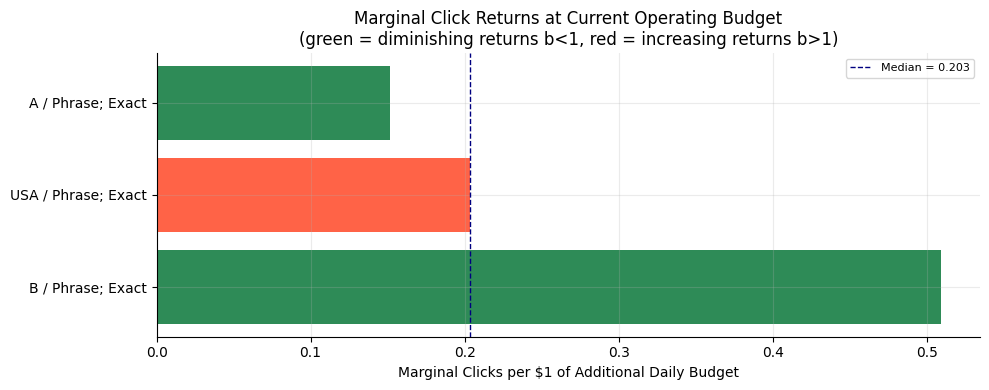


Highest marginal return segment: B / Phrase; Exact
  0.5092 clicks per $1 additional budget

Relative marginal return (vs. best):
segment
B / Phrase; Exact     1.000
USA / Phrase; Exact   0.400
A / Phrase; Exact     0.298


In [20]:
# Use the power-law fits from Analysis 1
# Marginal clicks per dollar at current (most recent 30-day average) budget

# Current budget = median of most recent 30-day window per segment
cutoff = campaign_day["date"].max() - pd.Timedelta(days=30)
recent = campaign_day[campaign_day["date"] >= cutoff]

marginal_rows = []

for rec in response_results:
    region, mt = rec["region"], rec["match_types"]
    a, b = rec["power_a"], rec["power_b"]
    r2 = rec["r2_power"]

    seg_recent = recent[(recent["region"] == region) & (recent["match_types"] == mt)]
    current_budget = seg_recent["daily_budget"].median() if not seg_recent.empty else np.nan

    if pd.isna(a) or pd.isna(current_budget):
        marginal = np.nan
        predicted_clicks = np.nan
    else:
        marginal = a * b * (current_budget ** (b - 1))     # d(clicks)/d(budget)
        predicted_clicks = power_law(current_budget, a, b)

    marginal_rows.append({
        "segment": rec["segment"],
        "region": region,
        "match_types": mt,
        "current_budget": round(current_budget, 2) if not pd.isna(current_budget) else np.nan,
        "power_b": b,
        "r2_power": r2,
        "predicted_clicks_at_budget": round(predicted_clicks, 1) if not pd.isna(predicted_clicks) else np.nan,
        "marginal_clicks_per_dollar": round(marginal, 4) if not pd.isna(marginal) else np.nan,
    })

marginal_df = pd.DataFrame(marginal_rows).set_index("segment").sort_values(
    "marginal_clicks_per_dollar", ascending=False
)

print("Marginal click return at current operating budget (power-law model):\n")
print(marginal_df[["current_budget", "power_b", "r2_power",
                    "predicted_clicks_at_budget", "marginal_clicks_per_dollar"]].to_string())

# Bar chart of marginal returns
valid = marginal_df.dropna(subset=["marginal_clicks_per_dollar"])
if not valid.empty:
    colors = ["seagreen" if b < 1 else "tomato" for b in valid["power_b"]]
    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(valid.index, valid["marginal_clicks_per_dollar"], color=colors)
    ax.set_xlabel("Marginal Clicks per $1 of Additional Daily Budget")
    ax.set_title("Marginal Click Returns at Current Operating Budget\n"
                 "(green = diminishing returns b<1, red = increasing returns b>1)")
    ax.axvline(valid["marginal_clicks_per_dollar"].median(), color="navy", ls="--", lw=1,
               label=f"Median = {valid['marginal_clicks_per_dollar'].median():.3f}")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig("figures/marginal-returns.png", dpi=150, bbox_inches="tight")
    plt.show()

# Budget reallocation headroom: difference from highest marginal return segment
best_marginal = valid["marginal_clicks_per_dollar"].max()
print(f"\nHighest marginal return segment: {valid['marginal_clicks_per_dollar'].idxmax()}")
print(f"  {best_marginal:.4f} clicks per $1 additional budget")
print("\nRelative marginal return (vs. best):")
print((valid["marginal_clicks_per_dollar"] / best_marginal).rename("fraction_of_best").to_string())

---

## Pooled Log-Linear Budget-Response Model

**Motivation**: most segments have only one historical budget level, so per-segment curve fitting (Analysis 1) only works for 5 of 12 segments. Under a multiplicative model

$$\text{clicks} = a_{\text{segment}} \cdot \text{budget}^{b} \cdot \varepsilon$$

the segment-level intercepts $a$ vary freely while the budget elasticity $b$ is shared. In log space this becomes a standard OLS with fixed effects:

$$\log(\text{clicks}) = \alpha_{\text{region}} + \mu_{\text{match\_type}} + b \cdot \log(\text{budget}) + \varepsilon$$

Each single-budget segment contributes its $N$ days as a precise anchor on the response curve; more days reduce noise in the intercept estimate and thereby tighten the shared $b$.

**Tests run:**
1. **Pooled model** â€” one shared $b$ for all segments.
2. **Match-type interaction** â€” $b$ allowed to vary by match-type group, testing whether elasticity differs between Broad, Exact, Phrase, and mixed configurations.
3. **Residual diagnostics** â€” check homoscedasticity and normality of residuals in log space.

In [21]:
import statsmodels.formula.api as smf
from scipy import stats as scipy_stats

# â”€â”€ Data prep â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Drop zero-click days (log undefined) but report how many are dropped
n_total = len(campaign_day)
model_df = campaign_day[campaign_day["clicks"] > 0].copy()
n_zero = n_total - len(model_df)
print(f"Campaign-days total : {n_total:,}")
print(f"Zero-click days dropped: {n_zero:,}  ({100*n_zero/n_total:.1f}%)")
print(f"Rows used in model  : {len(model_df):,}")

model_df["log_clicks"] = np.log(model_df["clicks"])
model_df["log_budget"] = np.log(model_df["daily_budget"])

# Treat region and match_types as categorical fixed effects
model_df["region"] = model_df["region"].astype("category")
model_df["match_types"] = model_df["match_types"].astype("category")

# â”€â”€ Model 1: Pooled (shared b) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
m1 = smf.ols("log_clicks ~ log_budget + C(region) + C(match_types)", data=model_df).fit()

print("\n" + "="*60)
print("MODEL 1 â€” Pooled (shared budget elasticity b)")
print("="*60)
print(m1.summary())
b_pooled = m1.params["log_budget"]
b_ci = m1.conf_int().loc["log_budget"]
print(f"\nBudget elasticity b = {b_pooled:.3f}  95% CI [{b_ci[0]:.3f}, {b_ci[1]:.3f}]")
print(f"Interpretation: 10% more budget â†’ {100*(1.1**b_pooled - 1):.1f}% more clicks")

Campaign-days total : 2,222
Zero-click days dropped: 0  (0.0%)
Rows used in model  : 2,222

MODEL 1 â€” Pooled (shared budget elasticity b)
                            OLS Regression Results                            
Dep. Variable:             log_clicks   R-squared:                       0.658
Model:                            OLS   Adj. R-squared:                  0.657
Method:                 Least Squares   F-statistic:                     609.6
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:31   Log-Likelihood:                -1499.3
No. Observations:                2222   AIC:                             3015.
Df Residuals:                    2214   BIC:                             3060.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                             coef    std err          

In [22]:
# â”€â”€ Model 2: Match-type interaction (b varies by match-type group) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Simplify match_types into broad groups to avoid too many interaction terms
def mt_group(mt):
    parts = {p.strip() for p in mt.split(";")}
    if parts == {"Broad"}:
        return "Broad"
    if parts == {"Exact"}:
        return "Exact"
    if parts == {"Phrase"}:
        return "Phrase"
    if "Broad" in parts and "Exact" in parts:
        return "Broad+Exact(+Phrase)"
    if "Exact" in parts and "Phrase" in parts:
        return "Exact+Phrase"
    if "Broad" in parts and "Phrase" in parts:
        return "Broad+Phrase"
    return "Other"

model_df["mt_group"] = model_df["match_types"].apply(mt_group).astype("category")

m2 = smf.ols(
    "log_clicks ~ log_budget * C(mt_group) + C(region)",
    data=model_df
).fit()

print("="*60)
print("MODEL 2 â€” Match-type interaction (b varies by match-type group)")
print("="*60)
print(m2.summary())

# Extract per-group b estimates
print("\nPer-match-type-group budget elasticity b:")
ref_group = model_df["mt_group"].cat.categories[0]
b_ref = m2.params["log_budget"]
print(f"  {ref_group:30s}  b = {b_ref:.3f}")
for param, val in m2.params.items():
    if "log_budget:C(mt_group)" in param:
        grp = param.split("[T.")[1].rstrip("]")
        b_grp = b_ref + val
        print(f"  {grp:30s}  b = {b_grp:.3f}  (diff from ref: {val:+.3f})")

# F-test: are the interaction terms jointly significant?
from statsmodels.stats.anova import anova_lm
anova_result = anova_lm(m1, m2)
print("\nLikelihood ratio / F-test: does b vary significantly by match-type group?")
print(anova_result)

# â”€â”€ Model 3: Region interaction (b varies by region) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
m3 = smf.ols(
    "log_clicks ~ log_budget * C(region) + C(match_types)",
    data=model_df
).fit()

print("="*60)
print("MODEL 3 â€” Region interaction (b varies by region)")
print("="*60)
ref_region = model_df["region"].cat.categories[0]
b_ref_r = m3.params["log_budget"]
print(f"  {ref_region:8s}  b = {b_ref_r:.3f}")
for param, val in m3.params.items():
    if "log_budget:C(region)" in param:
        rgn = param.split("[T.")[1].rstrip("]")
        b_r = b_ref_r + val
        print(f"  {rgn:8s}  b = {b_r:.3f}  (diff from ref: {val:+.3f})")

anova_r = anova_lm(m1, m3)
print("\nF-test: does b vary significantly by region?")
print(anova_r)

# â”€â”€ Model comparison summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
rows = []
for label, m in [("M1 pooled b", m1), ("M2 bÃ—match_type", m2), ("M3 bÃ—region", m3)]:
    rows.append({
        "model": label,
        "n_params": int(m.df_model + 1),
        "RÂ²": round(m.rsquared, 3),
        "RÂ²_adj": round(m.rsquared_adj, 3),
        "AIC": round(m.aic, 1),
        "BIC": round(m.bic, 1),
        "RMSE_log": round(np.sqrt(m.mse_resid), 4),
    })
print(pd.DataFrame(rows).set_index("model").to_string())

MODEL 2 â€” Match-type interaction (b varies by match-type group)
                            OLS Regression Results                            
Dep. Variable:             log_clicks   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     430.3
Date:                Fri, 22 May 2026   Prob (F-statistic):               0.00
Time:                        16:47:31   Log-Likelihood:                -1492.3
No. Observations:                2222   AIC:                             3007.
Df Residuals:                    2211   BIC:                             3069.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

C:\Users\jsitu\AppData\Local\Temp\ipykernel_9456\3671680055.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(resid_by_seg, labels=seg_order, vert=True)


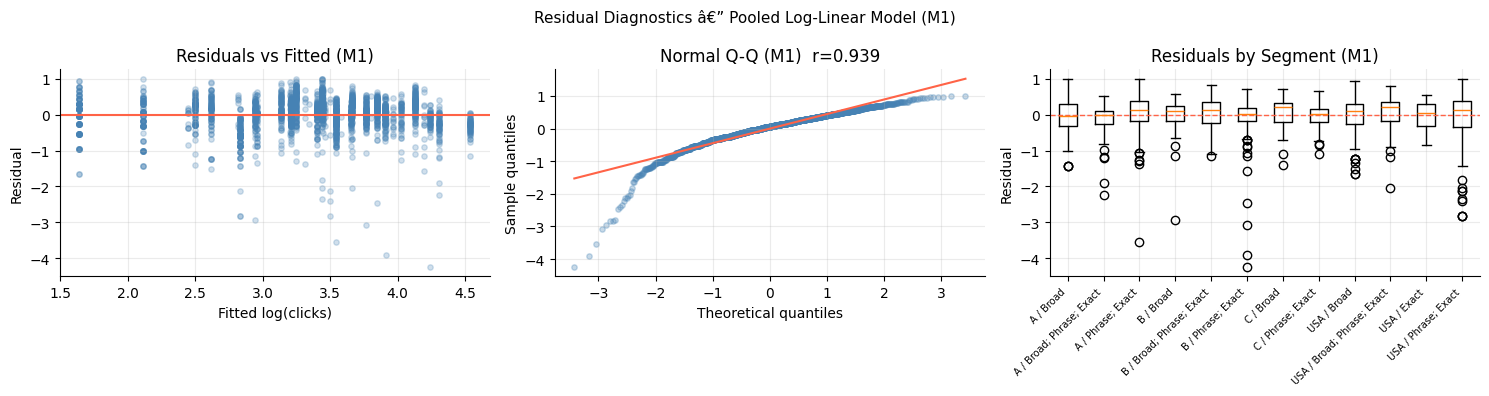

Shapiro-Wilk W=0.8831  p=5.0681e-38  (reject normality at Î±=0.05)


In [23]:
# â”€â”€ Residual diagnostics (Model 1) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
resid = m1.resid
fitted = m1.fittedvalues

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Residuals vs fitted
axes[0].scatter(fitted, resid, alpha=0.25, s=15, color="steelblue")
axes[0].axhline(0, color="tomato", lw=1.5)
axes[0].set_xlabel("Fitted log(clicks)")
axes[0].set_ylabel("Residual")
axes[0].set_title("Residuals vs Fitted (M1)")

# 2. QQ plot
(osm, osr), (slope, intercept, r) = scipy_stats.probplot(resid, dist="norm")
axes[1].scatter(osm, osr, alpha=0.3, s=15, color="steelblue")
axes[1].plot(osm, slope * np.array(osm) + intercept, color="tomato", lw=1.5)
axes[1].set_xlabel("Theoretical quantiles")
axes[1].set_ylabel("Sample quantiles")
axes[1].set_title(f"Normal Q-Q (M1)  r={r:.3f}")

# 3. Residuals by segment
seg_labels = (model_df["region"].astype(str) + " / " + model_df["match_types"].astype(str)).values
seg_order = sorted(set(seg_labels))
resid_by_seg = [resid[seg_labels == s].values for s in seg_order]
axes[2].boxplot(resid_by_seg, labels=seg_order, vert=True)
axes[2].axhline(0, color="tomato", lw=1, ls="--")
axes[2].set_xticklabels(seg_order, rotation=45, ha="right", fontsize=7)
axes[2].set_ylabel("Residual")
axes[2].set_title("Residuals by Segment (M1)")

plt.suptitle("Residual Diagnostics â€” Pooled Log-Linear Model (M1)", fontsize=11)
plt.tight_layout()
plt.savefig("figures/pooled-model-residuals.png", dpi=150, bbox_inches="tight")
plt.show()

# Shapiro-Wilk on a sample (max 5000 obs)
sw_stat, sw_p = scipy_stats.shapiro(resid.sample(min(len(resid), 5000), random_state=0))
print(f"Shapiro-Wilk W={sw_stat:.4f}  p={sw_p:.4e}  "
      f"({'reject normality' if sw_p < 0.05 else 'fail to reject normality'} at Î±=0.05)")

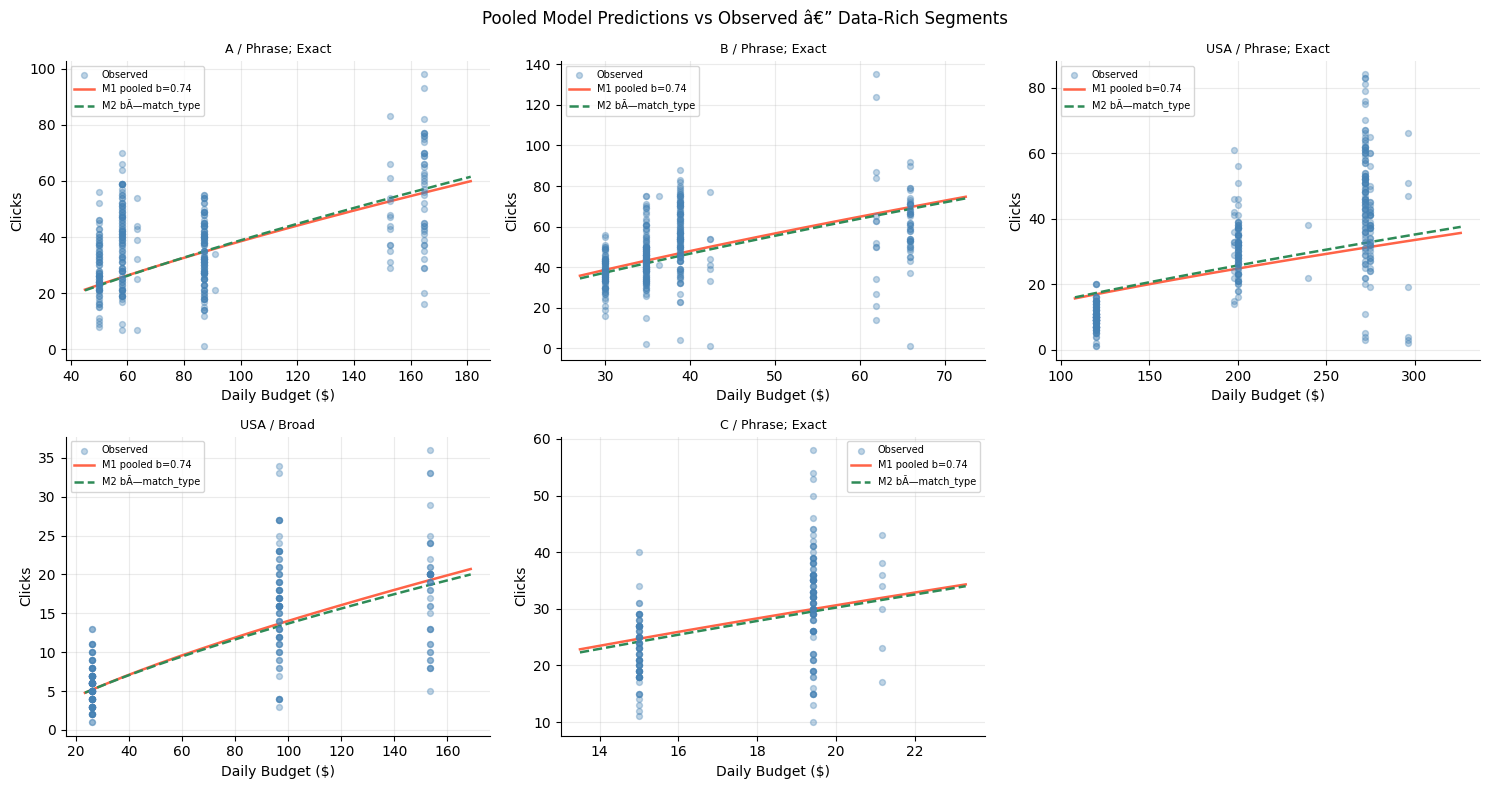

In [24]:
# â”€â”€ Predicted vs actual response curves per data-rich segment â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Overlay pooled model predictions on the scatter from Analysis 1

n_segs = len(rich_segs)
fig_cols = 3
fig_rows = -(-n_segs // fig_cols)
fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(15, 4 * fig_rows))
axes = axes.ravel()

for ax_i, (region, mt) in enumerate(rich_segs):
    sub = model_df[(model_df["region"] == region) & (model_df["match_types"] == mt)].copy()
    ax = axes[ax_i]

    ax.scatter(sub["daily_budget"], sub["clicks"], alpha=0.35, s=18,
               color="steelblue", label="Observed", zorder=3)

    # Pooled model prediction curve (M1) â€” hold FEs at this segment's levels
    b_grid = np.linspace(sub["daily_budget"].min() * 0.9, sub["daily_budget"].max() * 1.1, 200)
    pred_df = pd.DataFrame({
        "log_budget": np.log(b_grid),
        "region": pd.Categorical([region] * 200, categories=model_df["region"].cat.categories),
        "match_types": pd.Categorical([mt] * 200, categories=model_df["match_types"].cat.categories),
    })
    log_pred = m1.predict(pred_df)
    ax.plot(b_grid, np.exp(log_pred), color="tomato", lw=1.8,
            label=f"M1 pooled b={b_pooled:.2f}")

    # M2 prediction (b varies by match-type group)
    grp = mt_group(mt)
    pred_df2 = pred_df.copy()
    pred_df2["mt_group"] = pd.Categorical([grp] * 200, categories=model_df["mt_group"].cat.categories)
    log_pred2 = m2.predict(pred_df2)
    ax.plot(b_grid, np.exp(log_pred2), color="seagreen", lw=1.8, ls="--",
            label=f"M2 bÃ—match_type")

    ax.set_title(f"{region} / {mt}", fontsize=9)
    ax.set_xlabel("Daily Budget ($)")
    ax.set_ylabel("Clicks")
    ax.legend(fontsize=7)

for j in range(ax_i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Pooled Model Predictions vs Observed â€” Data-Rich Segments", fontsize=12)
plt.tight_layout()
plt.savefig("figures/pooled-model-fit.png", dpi=150, bbox_inches="tight")
plt.show()

---

## Feature Engineering

Add temporal, demand, and keyword semantic features to the campaign-day panel. Feature definitions follow `ad_opt/utils/date_features.py`.

**Temporal features**
- `day_of_week` — weekday name
- `is_weekend` — 1 if Sat/Sun
- `month` — 3-letter month label
- `is_public_holiday` — 1 if a public holiday in the region's representative country (USA→US, A→UK, B→Singapore, C→US fallback)
- `days_to_next_course_start` — days until the next System Thinking course start (negative = past most recent start)

**Keyword semantic features** (from the BERT analysis above)
- `embed_cohesion`, `embed_dispersion`, `embed_course_sim_mean`, `embed_course_sim_p90` — joined via `keyword_set_id`

**Not available without a GKP pull**
- Monthly search volume trends (`last_month_searches`, `search_trend`, etc.)
- Competition index, bid ranges

In [25]:
import holidays

# ── Course start dates (from ad_opt config) ───────────────────────────────────
SYS_THINK_START_DATES = sorted(pd.to_datetime([
    "2021-01-25", "2021-04-05", "2021-10-04",
    "2022-01-31", "2022-04-25", "2022-10-03",
    "2023-01-30", "2023-04-10", "2023-10-02",
    "2024-02-05", "2024-04-08", "2024-10-07",
    "2025-02-10", "2025-04-14", "2025-10-06",
    "2026-02-02", "2026-04-06", "2026-06-15",
]))

def days_to_next_start(date, start_dates):
    """Days until next course start; negative = days since most recent past start."""
    future = [d for d in start_dates if d >= date]
    if future:
        return (min(future) - date).days
    return (max(start_dates) - date).days  # all past → days since last (negative)


# ── Holiday calendars by region ───────────────────────────────────────────────
# Region → representative country code for the holidays library
REGION_HOLIDAY_COUNTRY = {"USA": "US", "A": "GB", "B": "SG", "C": "US"}

def build_holiday_set(country_code, years):
    try:
        return holidays.country_holidays(country_code, years=years)
    except Exception:
        return {}


# ── Build enriched panel ──────────────────────────────────────────────────────
feat_df = campaign_day.copy()

# Merge keyword_set_id from campaign_summary
feat_df = feat_df.merge(
    campaign_summary[["campaign_version", "keyword_set_id"]],
    on="campaign_version", how="left"
)

# Temporal features
feat_df["day_of_week"] = feat_df["date"].dt.day_name()
feat_df["is_weekend"] = feat_df["date"].dt.dayofweek.isin([5, 6]).astype(int)
feat_df["month"] = feat_df["date"].dt.strftime("%b")
feat_df["days_to_next_course_start"] = feat_df["date"].apply(
    lambda d: days_to_next_start(d, SYS_THINK_START_DATES)
)

# Public holiday by region
years_covered = range(feat_df["date"].dt.year.min(), feat_df["date"].dt.year.max() + 2)
holiday_cals = {
    region: build_holiday_set(code, years_covered)
    for region, code in REGION_HOLIDAY_COUNTRY.items()
}
feat_df["is_public_holiday"] = feat_df.apply(
    lambda r: int(r["date"] in holiday_cals.get(r["region"], {})), axis=1
)

# ── Keyword semantic features (set-level) ────────────────────────────────────
# Rebuild set-level semantic features from the earlier analysis
KEYWORD_SETS_PATH = DATA_DIR / "campaign-keyword-sets.csv"
EMBEDDINGS_CACHE_PATH = DATA_DIR / "keyword_embeddings.parquet"

kw_sets_df2 = pd.read_csv(KEYWORD_SETS_PATH)

COURSE_ANCHORS = [
    "system thinking",
    "systems thinking",
    "MIT xPRO system thinking",
    "MIT xPRO systems thinking",
]

def parse_kw_list2(s):
    if pd.isna(s) or str(s).strip() == "":
        return []
    return [k.strip() for k in str(s).split(";") if k.strip()]


if EMBEDDINGS_CACHE_PATH.exists():
    emb_df = pd.read_parquet(EMBEDDINGS_CACHE_PATH)
    kw_to_emb = {row["keyword"]: np.array(row["embedding"]) for _, row in emb_df.iterrows()}

    anchor_embs = np.array([kw_to_emb[a] for a in COURSE_ANCHORS if a in kw_to_emb])

    sem_rows = []
    for _, ks_row in kw_sets_df2.iterrows():
        kws = parse_kw_list2(ks_row["unique_keywords"])
        vecs = np.array([kw_to_emb[k] for k in kws if k in kw_to_emb])
        if len(vecs) < 2:
            sem_rows.append({"keyword_set_id": ks_row["keyword_set_id"],
                             "embed_cohesion": np.nan, "embed_dispersion": np.nan,
                             "embed_course_sim_mean": np.nan, "embed_course_sim_p90": np.nan})
            continue
        # Cohesion: mean pairwise cosine similarity
        norms = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)
        pairwise = norms @ norms.T
        mask = np.triu(np.ones_like(pairwise, dtype=bool), k=1)
        cohesion = pairwise[mask].mean()
        dispersion = 1 - cohesion
        # Course similarity
        if len(anchor_embs):
            anchor_norms = anchor_embs / (np.linalg.norm(anchor_embs, axis=1, keepdims=True) + 1e-9)
            sims = norms @ anchor_norms.T
            course_sims = sims.max(axis=1)
            course_sim_mean = course_sims.mean()
            course_sim_p90 = np.percentile(course_sims, 90)
        else:
            course_sim_mean = course_sim_p90 = np.nan
        sem_rows.append({"keyword_set_id": ks_row["keyword_set_id"],
                         "embed_cohesion": cohesion, "embed_dispersion": dispersion,
                         "embed_course_sim_mean": course_sim_mean,
                         "embed_course_sim_p90": course_sim_p90})

    sem_features_df = pd.DataFrame(sem_rows)
    feat_df = feat_df.merge(sem_features_df, on="keyword_set_id", how="left")
    sem_feat_cols = ["embed_cohesion", "embed_dispersion", "embed_course_sim_mean", "embed_course_sim_p90"]
    print(f"Semantic features merged. Non-null rate: {feat_df[sem_feat_cols].notna().mean().round(3).to_dict()}")
else:
    sem_feat_cols = []
    print("Embedding cache not found — semantic features skipped.")

print(f"\nEnriched panel shape: {feat_df.shape}")
print(feat_df[["date", "region", "daily_budget", "clicks",
               "day_of_week", "is_weekend", "month",
               "is_public_holiday", "days_to_next_course_start"]].head(8).to_string(index=False))
print(f"\nHoliday rate by region:")
print(feat_df.groupby("region")["is_public_holiday"].mean().round(3).to_string())
print(f"\ndays_to_next_course_start range: {feat_df['days_to_next_course_start'].min()} to {feat_df['days_to_next_course_start'].max()}")

Semantic features merged. Non-null rate: {'embed_cohesion': 1.0, 'embed_dispersion': 1.0, 'embed_course_sim_mean': 1.0, 'embed_course_sim_p90': 1.0}

Enriched panel shape: (2222, 17)
      date region  daily_budget  clicks day_of_week  is_weekend month  is_public_holiday  days_to_next_course_start
2024-06-26      B        38.830       4   Wednesday           0   Jun                  0                        103
2024-06-27      A        58.250       9    Thursday           0   Jun                  0                        102
2024-06-27      B        38.830      78    Thursday           0   Jun                  0                        102
2024-06-27      C        19.420      10    Thursday           0   Jun                  0                        102
2024-06-27    USA       271.840       3    Thursday           0   Jun                  0                        102
2024-06-28      A        58.250       7      Friday           0   Jun                  0                        101
2024-

---

## Linear Model with Features (M4)

A level-level linear model with budget interacted per segment plus temporal and keyword features:

$$\text{clicks} = \sum_s \beta_s \cdot \text{budget} \cdot \mathbf{1}[\text{segment}=s] + \gamma_1 \cdot \text{day\_of\_week} + \gamma_2 \cdot \text{is\_holiday} + \gamma_3 \cdot \text{days\_to\_start} + \gamma_4 \cdot \text{kw\_features} + \alpha_s + \varepsilon$$

The per-segment budget slope $\beta_s$ is the **marginal clicks per dollar** directly, without needing a parametric response curve. This is simpler to interpret than the power-law derivative and naturally handles segments with limited budget variation by borrowing the intercept from FEs.

In [26]:
lin_df = feat_df.copy()
lin_df["segment"] = lin_df["region"].astype(str) + " / " + lin_df["match_types"].astype(str)

# ── M4a: linear level-level with temporal + kw features, shared budget slope ──
base_formula = (
    "clicks ~ daily_budget"
    " + C(region) + C(match_types)"
    " + C(day_of_week) + is_weekend + C(month)"
    " + is_public_holiday"
    " + days_to_next_course_start"
)

# Add semantic features if available
sem_terms = " + ".join(sem_feat_cols)
if sem_terms:
    formula_4a = base_formula + " + " + sem_terms
else:
    formula_4a = base_formula

m4a = smf.ols(formula_4a, data=lin_df).fit()

print("="*60)
print("MODEL M4a — Linear, shared budget slope, with features")
print("="*60)
print(f"R²={m4a.rsquared:.3f}  Adj-R²={m4a.rsquared_adj:.3f}  AIC={m4a.aic:.1f}  RMSE={np.sqrt(m4a.mse_resid):.2f}")
print()
b4a = m4a.params["daily_budget"]
b4a_ci = m4a.conf_int().loc["daily_budget"]
print(f"Shared marginal return: {b4a:.4f} clicks/$1  (95% CI [{b4a_ci[0]:.4f}, {b4a_ci[1]:.4f}])")

# Significant temporal features
sig = m4a.pvalues[m4a.pvalues < 0.05].drop("Intercept", errors="ignore")
print(f"\nSignificant features (p<0.05): {len(sig)}")
print(sig.sort_values().to_string())

# ── M4b: per-segment budget slope (budget × segment interaction) ───────────────
formula_4b = (
    "clicks ~ daily_budget * C(segment)"
    " + C(day_of_week) + is_weekend + C(month)"
    " + is_public_holiday"
    " + days_to_next_course_start"
)
if sem_terms:
    formula_4b += " + " + sem_terms

m4b = smf.ols(formula_4b, data=lin_df).fit()

print("\n" + "="*60)
print("MODEL M4b — Linear, per-segment budget slope, with features")
print("="*60)
print(f"R²={m4b.rsquared:.3f}  Adj-R²={m4b.rsquared_adj:.3f}  AIC={m4b.aic:.1f}  RMSE={np.sqrt(m4b.mse_resid):.2f}")

# Extract per-segment marginal return (budget slope)
ref_seg = lin_df["segment"].unique()[0]
b_ref_4b = m4b.params["daily_budget"]

marginal_linear = {}
marginal_linear[ref_seg] = b_ref_4b
for pname, val in m4b.params.items():
    if "daily_budget:C(segment)" in pname:
        seg = pname.split("[T.")[1].rstrip("]")
        marginal_linear[seg] = b_ref_4b + val

print("\nPer-segment marginal return — M4b (clicks per $1 of daily budget):")
for seg, m in sorted(marginal_linear.items(), key=lambda x: -x[1]):
    print(f"  {seg:35s}  {m:.4f}")

# F-test vs M4a: do per-segment slopes add value?
anova_4 = anova_lm(m4a, m4b)
print("\nF-test: M4a vs M4b (do per-segment slopes add?)")
print(anova_4)

MODEL M4a — Linear, shared budget slope, with features
R²=0.667  Adj-R²=0.663  AIC=17901.8  RMSE=13.50

Shared marginal return: 0.1506 clicks/$1  (95% CI [0.1340, 0.1673])

Significant features (p<0.05): 21
C(match_types)[T.Broad; Phrase; Exact]   0.000
C(region)[T.B]                           0.000
daily_budget                             0.000
C(region)[T.USA]                         0.000
C(month)[T.May]                          0.000
embed_course_sim_mean                    0.000
embed_cohesion                           0.000
C(day_of_week)[T.Monday]                 0.000
embed_dispersion                         0.000
embed_course_sim_p90                     0.000
C(region)[T.C]                           0.000
C(day_of_week)[T.Tuesday]                0.000
C(month)[T.Feb]                          0.000
C(month)[T.Dec]                          0.000
C(match_types)[T.Phrase; Exact]          0.000
C(day_of_week)[T.Thursday]               0.000
C(month)[T.Jun]                          

Full model comparison:
                                 scale  n_params    R²  R²_adj        AIC   RMSE
model                                                                           
M1  log-log pooled b           log-log         8 0.658   0.657  3,014.600  0.476
M2  log-log b×match_type       log-log        11 0.661   0.659  3,006.500  0.475
M3  log-log b×region           log-log        11 0.664   0.663  2,983.300  0.472
M4a linear shared slope+feats    level        30 0.667   0.663 17,901.800 13.500
M4b linear seg slopes+feats      level        43 0.737   0.732 17,406.800 12.042


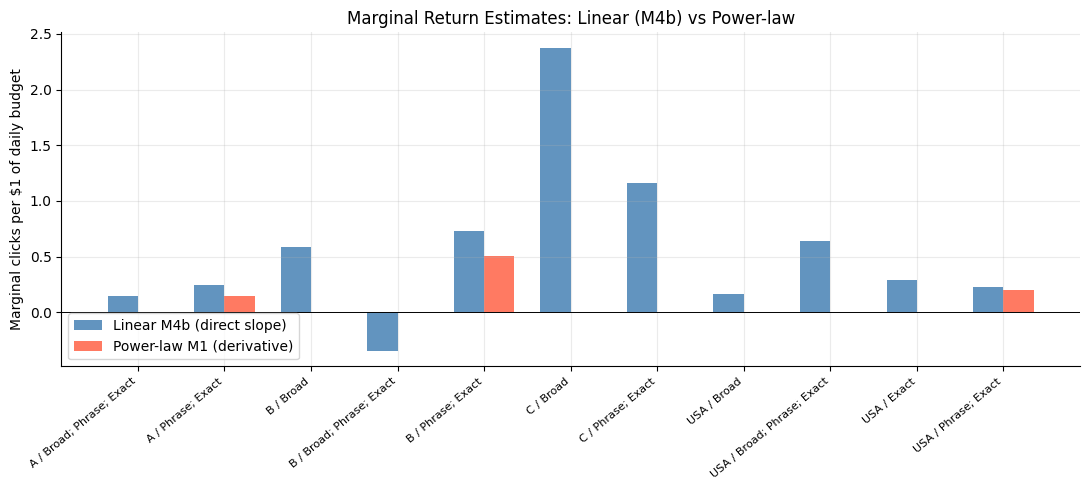


Top temporal/feature coefficients (M4b), t-stats:
  C(day_of_week)[T.Monday]                       coef=   7.655  t=  7.99  ***
  C(day_of_week)[T.Tuesday]                      coef=   6.082  t=  6.30  ***
  C(month)[T.Nov]                                coef=  11.010  t=  5.58  ***
  C(month)[T.Sep]                                coef=  10.203  t=  5.54  ***
  C(month)[T.Jul]                                coef=   9.082  t=  4.82  ***
  C(month)[T.Aug]                                coef=   8.682  t=  4.77  ***
  C(day_of_week)[T.Thursday]                     coef=   4.228  t=  4.40  ***
  C(month)[T.Oct]                                coef=   8.821  t=  4.25  ***
  C(month)[T.Jan]                                coef=   6.156  t=  3.39  ***
  C(day_of_week)[T.Wednesday]                    coef=   3.158  t=  3.29  **
  embed_course_sim_mean                          coef=-264.355  t=  3.03  **
  embed_dispersion                               coef=-121.820  t=  3.02  **
  C(month)[T.May

In [27]:
# ── Full model comparison ─────────────────────────────────────────────────────
all_models = [
    ("M1  log-log pooled b",           m1,  "log-log"),
    ("M2  log-log b×match_type",       m2,  "log-log"),
    ("M3  log-log b×region",           m3,  "log-log"),
    ("M4a linear shared slope+feats",  m4a, "level"),
    ("M4b linear seg slopes+feats",    m4b, "level"),
]

comp_rows = []
for label, m, scale in all_models:
    comp_rows.append({
        "model": label,
        "scale": scale,
        "n_params": int(m.df_model + 1),
        "R²": round(m.rsquared, 3),
        "R²_adj": round(m.rsquared_adj, 3),
        "AIC": round(m.aic, 1),
        "RMSE": round(np.sqrt(m.mse_resid), 4),
    })

comp_df = pd.DataFrame(comp_rows).set_index("model")
print("Full model comparison:")
print(comp_df.to_string())

# ── Visualise: per-segment marginal returns comparison ────────────────────────
# Power-law marginals (from Analysis 5) vs linear M4b marginals
pow_marginals = {rec["segment"]: rec["marginal_clicks_per_dollar"]
                 for rec in marginal_rows if not pd.isna(rec.get("marginal_clicks_per_dollar"))}
lin_marginals_valid = {s: v for s, v in marginal_linear.items() if not pd.isna(v)}

all_segs = sorted(set(lin_marginals_valid) | set(pow_marginals))
lin_vals = [lin_marginals_valid.get(s, np.nan) for s in all_segs]
pow_vals = [pow_marginals.get(s, np.nan) for s in all_segs]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(all_segs))
w = 0.35
bars1 = ax.bar(x - w/2, lin_vals, w, label="Linear M4b (direct slope)", color="steelblue", alpha=0.85)
bars2 = ax.bar(x + w/2, pow_vals, w, label="Power-law M1 (derivative)", color="tomato", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_segs, rotation=40, ha="right", fontsize=8)
ax.set_ylabel("Marginal clicks per $1 of daily budget")
ax.set_title("Marginal Return Estimates: Linear (M4b) vs Power-law")
ax.legend()
ax.axhline(0, color="black", lw=0.7)
plt.tight_layout()
plt.savefig("figures/marginal-returns-comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Feature importance: standardised coefficients from M4b
print("\nTop temporal/feature coefficients (M4b), t-stats:")
feat_params = m4b.tvalues.drop([p for p in m4b.tvalues.index
                                  if "daily_budget" in p or "C(segment)" in p or p == "Intercept"],
                                errors="ignore")
top_feats = feat_params.abs().sort_values(ascending=False).head(15)
for feat, tstat in top_feats.items():
    coef = m4b.params[feat]
    pval = m4b.pvalues[feat]
    star = "***" if pval < 0.001 else ("**" if pval < 0.01 else ("*" if pval < 0.05 else ""))
    print(f"  {feat:45s}  coef={coef:8.3f}  t={tstat:6.2f}  {star}")

---

## All-Conversions Analysis

Repeat the budget-response and marginal-return analyses using **All conv.** as the
outcome variable instead of clicks. Source: `data/sys_think/reports/Search keyword - raw input to models - all conv.csv`.


In [28]:
import holidays
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

ALLCONV_REPORT_PATH = Path('data/sys_think/reports') / 'Search keyword - raw input to models - all conv.csv'

allconv_raw = pd.read_csv(
    ALLCONV_REPORT_PATH,
    skiprows=2,
    parse_dates=['Day'],
    encoding='utf-8',
)
allconv_raw.rename(columns={'Day': 'date', 'All conv.': 'all_conv'}, inplace=True)
allconv_raw['all_conv'] = pd.to_numeric(allconv_raw['all_conv'], errors='coerce').fillna(0.0)

# Aggregate to (campaign, date)
allconv_day_raw = (
    allconv_raw
    .groupby(['date', 'Campaign'], as_index=False)
    .agg(all_conv=('all_conv', 'sum'))
)

# Map campaign name → region + match_types via campaign_summary
cv_region = campaign_summary.merge(
    campaign_day[['campaign_version', 'region']].drop_duplicates(),
    on='campaign_version', how='left'
)
camp_to_region = cv_region.dropna(subset=['region']).groupby('campaign')['region'].first().to_dict()
camp_to_mt = cv_region.sort_values('start_date').groupby('campaign')['match_types'].last().to_dict()

allconv_day_raw['region'] = allconv_day_raw['Campaign'].map(camp_to_region)
allconv_day_raw['match_types'] = allconv_day_raw['Campaign'].map(camp_to_mt)

def infer_region(name):
    n = str(name)
    if any(x in n for x in ['- USA', '- US -', 'Prospecting - USA']): return 'USA'
    if 'Prospecting - A' in n or '- A -' in n: return 'A'
    if 'Prospecting - B' in n or '- B -' in n: return 'B'
    if 'Prospecting - C' in n or '- C -' in n: return 'C'
    return None

def infer_mt(name):
    n = str(name)
    has_b, has_e, has_p = 'Broad' in n, 'Exact' in n, 'Phrase' in n
    if has_b and has_e and has_p: return 'Broad; Exact; Phrase'
    if has_b and has_e: return 'Broad; Exact'
    if has_b and has_p: return 'Broad; Phrase'
    if has_e and has_p: return 'Exact; Phrase'
    if has_b: return 'Broad'
    if has_e: return 'Exact'
    if has_p: return 'Phrase'
    return None

mask_r = allconv_day_raw['region'].isna()
allconv_day_raw.loc[mask_r, 'region'] = allconv_day_raw.loc[mask_r, 'Campaign'].apply(infer_region)
mask_m = allconv_day_raw['match_types'].isna()
allconv_day_raw.loc[mask_m, 'match_types'] = allconv_day_raw.loc[mask_m, 'Campaign'].apply(infer_mt)
allconv_day_raw = allconv_day_raw.dropna(subset=['region', 'match_types'])

# Aggregate to (date, region, match_types)
allconv_seg = (
    allconv_day_raw
    .groupby(['date', 'region', 'match_types'], as_index=False)
    .agg(all_conv=('all_conv', 'sum'))
)

def norm_mt(s):
    return '; '.join(sorted([x.strip() for x in str(s).split(';')]))

campaign_day['_mt_norm'] = campaign_day['match_types'].apply(norm_mt)
allconv_seg['_mt_norm'] = allconv_seg['match_types'].apply(norm_mt)

conv_day = allconv_seg.merge(
    campaign_day[['date', 'region', '_mt_norm', 'daily_budget', 'clicks', 'match_types']]
    .rename(columns={'match_types': 'match_types_cd'}),
    left_on=['date', 'region', '_mt_norm'],
    right_on=['date', 'region', '_mt_norm'],
    how='inner'
).drop(columns=['_mt_norm', 'match_types']).rename(columns={'match_types_cd': 'match_types'})
conv_day.drop_duplicates(subset=['date', 'region', 'match_types'], inplace=True)

print(f'All-conv panel: {len(conv_day):,} rows  |  '
      f'{conv_day["date"].min().date()} – {conv_day["date"].max().date()}')
print(f'Total all_conv: {conv_day["all_conv"].sum():,.1f}')
print(f'Zero-conv days: {(conv_day["all_conv"]==0).sum()} / {len(conv_day)} '
      f'({100*(conv_day["all_conv"]==0).mean():.1f}%)')
conv_day.groupby(['region', 'match_types'])['all_conv'].describe().round(2)


All-conv panel: 1,392 rows  |  2024-06-26 – 2026-05-13
Total all_conv: 3,049.7
Zero-conv days: 536 / 1392 (38.5%)


count  mean   std   min   25%   50%   75%    max
region match_types                                                     
A      Broad          77.000 0.250 0.520 0.000 0.000 0.000 0.000  2.000
       Phrase; Exact 359.000 3.350 3.900 0.000 0.540 2.000 5.000 27.000
B      Broad          78.000 1.280 1.480 0.000 0.000 1.000 2.000  6.000
       Phrase; Exact 362.000 3.540 3.250 0.000 1.000 3.000 5.000 19.000
C      Broad          77.000 0.360 0.650 0.000 0.000 0.000 1.000  3.000
       Phrase; Exact 187.000 1.070 1.670 0.000 0.000 0.000 1.000  9.000
USA    Broad         226.000 0.790 1.970 0.000 0.000 0.000 1.000 19.000
       Exact          11.000 1.230 1.290 0.000 0.250 1.000 1.500  3.990
       Phrase; Exact  15.000 1.830 2.330 0.000 0.000 1.000 3.000  7.000

### Budget-response curve viability (all conv.)


Distinct budget levels per segment:
region  match_types  
A       Phrase; Exact    7
B       Phrase; Exact    7
USA     Broad            3
C       Phrase; Exact    3
USA     Phrase; Exact    2
A       Broad            1
B       Broad            1
C       Broad            1
USA     Exact            1

Segments with >=3 budget levels: 4


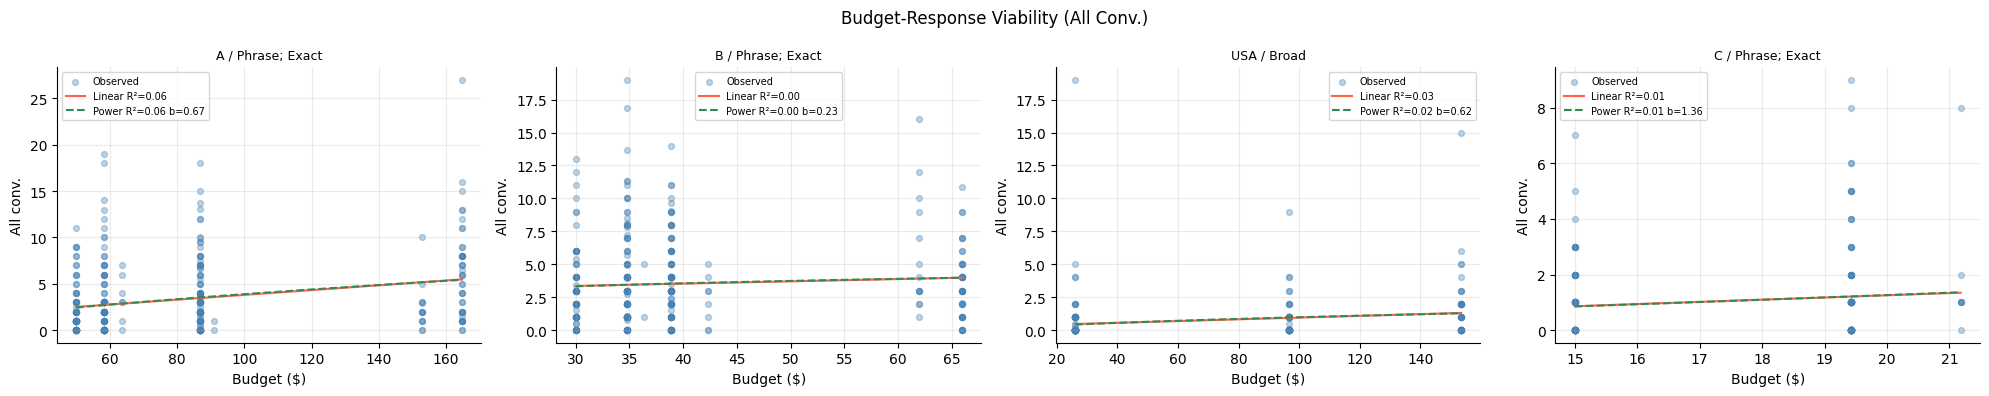

,region,match_types,n_days,n_budget_levels,r2_linear,r2_power,power_a,power_b
segment,,,,,,,,
A / Phrase; Exact,A,Phrase; Exact,359,7,0.064,0.063,0.178,0.670
B / Phrase; Exact,B,Phrase; Exact,362,7,0.004,0.004,1.540,0.227
USA / Broad,USA,Broad,226,3,0.028,0.025,0.057,0.617
C / Phrase; Exact,C,Phrase; Exact,187,3,0.011,0.012,0.022,1.358


In [29]:
def power_law(x, a, b):
    return a * np.power(x, b)

seg_budget_counts_c = (
    conv_day.groupby(['region', 'match_types'])['daily_budget']
    .nunique().sort_values(ascending=False)
)
print('Distinct budget levels per segment:')
print(seg_budget_counts_c.to_string())

rich_segs_c = seg_budget_counts_c[seg_budget_counts_c >= 3].index.tolist()
print(f'\nSegments with >=3 budget levels: {len(rich_segs_c)}')

response_results_c = []
n_sc = len(rich_segs_c)
fig, axes = plt.subplots(1, n_sc, figsize=(5 * n_sc, 4))
if n_sc == 1: axes = [axes]

for ax_i, (region, mt) in enumerate(rich_segs_c):
    sub = conv_day[(conv_day['region']==region) & (conv_day['match_types']==mt)]
    X, y = sub['daily_budget'].values, sub['all_conv'].values
    coeffs = np.polyfit(X, y, 1)
    r2_lin = r2_score(y, np.polyval(coeffs, X))
    try:
        popt, _ = curve_fit(power_law, X, y, p0=[0.01, 0.8],
                            bounds=([0, 0], [np.inf, 3]), maxfev=20000)
        r2_pow = r2_score(y, power_law(X, *popt))
        pow_b = popt[1]
    except Exception:
        popt, r2_pow, pow_b = None, np.nan, np.nan
    response_results_c.append(dict(segment=f'{region} / {mt}', region=region,
                                   match_types=mt, n_days=len(sub),
                                   n_budget_levels=int(sub['daily_budget'].nunique()),
                                   r2_linear=round(r2_lin, 3),
                                   r2_power=round(r2_pow, 3) if not np.isnan(r2_pow) else np.nan,
                                   power_a=round(popt[0], 6) if popt is not None else np.nan,
                                   power_b=round(pow_b, 4) if not np.isnan(pow_b) else np.nan))
    ax = axes[ax_i]
    ax.scatter(X, y, alpha=0.35, s=18, color='steelblue', label='Observed')
    xl = np.linspace(X.min(), X.max(), 200)
    ax.plot(xl, np.polyval(coeffs, xl), color='tomato', lw=1.5, label=f'Linear R²={r2_lin:.2f}')
    if popt is not None:
        ax.plot(xl, power_law(xl, *popt), color='seagreen', lw=1.5, ls='--',
                label=f'Power R²={r2_pow:.2f} b={pow_b:.2f}')
    ax.set_title(f'{region} / {mt}', fontsize=9)
    ax.set_xlabel('Budget ($)'); ax.set_ylabel('All conv.')
    ax.legend(fontsize=7)

fig.suptitle('Budget-Response Viability (All Conv.)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/allconv-budget-response-viability.png', dpi=150, bbox_inches='tight')
plt.show()
pd.DataFrame(response_results_c).set_index('segment')

### Pooled log-linear conversion models (M1–M3)


In [30]:
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from scipy import stats as scipy_stats

n_total_c = len(conv_day)
model_df_c = conv_day[conv_day['all_conv'] > 0].copy()
print(f'Zero-conv days dropped: {n_total_c - len(model_df_c)} ({100*(n_total_c-len(model_df_c))/n_total_c:.1f}%)')
print(f'Rows used: {len(model_df_c):,}')

model_df_c['log_conv'] = np.log(model_df_c['all_conv'])
model_df_c['log_budget'] = np.log(model_df_c['daily_budget'])
model_df_c['region'] = model_df_c['region'].astype('category')
model_df_c['match_types'] = model_df_c['match_types'].astype('category')

def mt_group(mt):
    parts = {p.strip() for p in str(mt).split(';')}
    if parts == {'Broad'}: return 'Broad'
    if parts == {'Exact'}: return 'Exact'
    if parts == {'Phrase'}: return 'Phrase'
    if 'Broad' in parts and 'Exact' in parts: return 'Broad+Exact(+Phrase)'
    if 'Exact' in parts and 'Phrase' in parts: return 'Exact+Phrase'
    if 'Broad' in parts and 'Phrase' in parts: return 'Broad+Phrase'
    return 'Other'

model_df_c['mt_group'] = model_df_c['match_types'].apply(mt_group).astype('category')

mc1 = smf.ols('log_conv ~ log_budget + C(region) + C(match_types)', data=model_df_c).fit()
mc2 = smf.ols('log_conv ~ log_budget * C(mt_group) + C(region)', data=model_df_c).fit()
mc3 = smf.ols('log_conv ~ log_budget * C(region) + C(match_types)', data=model_df_c).fit()

b_c = mc1.params['log_budget']; b_ci_c = mc1.conf_int().loc['log_budget']
print(f'\nM1 pooled b = {b_c:.3f}  95% CI [{b_ci_c[0]:.3f}, {b_ci_c[1]:.3f}]')
print(f'10% more budget → {100*(1.1**b_c - 1):.1f}% more conversions')

rows_c = []
for label, m in [('M1 pooled b', mc1), ('M2 b×match_type', mc2), ('M3 b×region', mc3)]:
    rows_c.append(dict(model=label, n_params=int(m.df_model+1),
                       R2=round(m.rsquared, 3), AIC=round(m.aic, 1),
                       RMSE_log=round(np.sqrt(m.mse_resid), 4)))
pd.DataFrame(rows_c).set_index('model')


Zero-conv days dropped: 536 (38.5%)
Rows used: 856

M1 pooled b = 0.329  95% CI [0.183, 0.475]
10% more budget → 3.2% more conversions


,n_params,R2,AIC,RMSE_log
model,,,,
M1 pooled b,7,0.146,"2,074.800",0.810
M2 b×match_type,8,0.146,"2,076.700",0.810
M3 b×region,10,0.151,"2,076.100",0.809


### Linear model with features — all conv. (M4a / M4b)


In [31]:
SYS_THINK_START_DATES = sorted(pd.to_datetime([
    '2024-02-05', '2024-04-08', '2024-10-07',
    '2025-02-10', '2025-04-14', '2025-10-06',
    '2026-02-02', '2026-04-06', '2026-06-15',
]))

def days_to_next_start(date, starts):
    future = [d for d in starts if d >= date]
    return (min(future) - date).days if future else (max(starts) - date).days

REGION_HOLIDAY_COUNTRY = {'USA': 'US', 'A': 'GB', 'B': 'SG', 'C': 'US'}

feat_df_c = conv_day.copy()
feat_df_c = feat_df_c.merge(
    campaign_day_ts[['date', 'region', 'match_types', 'keyword_set_id']].drop_duplicates(),
    on=['date', 'region', 'match_types'], how='left'
)
feat_df_c['day_of_week'] = feat_df_c['date'].dt.day_name()
feat_df_c['is_weekend'] = feat_df_c['date'].dt.dayofweek.isin([5, 6]).astype(int)
feat_df_c['month'] = feat_df_c['date'].dt.strftime('%b')
feat_df_c['days_to_next_course_start'] = feat_df_c['date'].apply(
    lambda d: days_to_next_start(d, SYS_THINK_START_DATES)
)
years_c = range(feat_df_c['date'].dt.year.min(), feat_df_c['date'].dt.year.max() + 2)
hols_c = {r: holidays.country_holidays(c, years=years_c)
           for r, c in REGION_HOLIDAY_COUNTRY.items()}
feat_df_c['is_public_holiday'] = feat_df_c.apply(
    lambda r: int(r['date'] in hols_c.get(r['region'], {})), axis=1
)

if EMBEDDINGS_CACHE_PATH.exists():
    feat_df_c = feat_df_c.merge(sem_features_df, on='keyword_set_id', how='left')

feat_df_c['segment'] = feat_df_c['region'].astype(str) + ' / ' + feat_df_c['match_types'].astype(str)

base_f = ('all_conv ~ daily_budget + C(region) + C(match_types)'
          ' + C(day_of_week) + is_weekend + C(month)'
          ' + is_public_holiday + days_to_next_course_start')
sem_t = ' + '.join(sem_feat_cols) if sem_feat_cols else ''
formula_c4a = base_f + (' + ' + sem_t if sem_t else '')
formula_c4b = ('all_conv ~ daily_budget * C(segment)'
               ' + C(day_of_week) + is_weekend + C(month)'
               ' + is_public_holiday + days_to_next_course_start'
               + (' + ' + sem_t if sem_t else ''))

mc4a = smf.ols(formula_c4a, data=feat_df_c).fit()
mc4b = smf.ols(formula_c4b, data=feat_df_c).fit()

print(f'M4a  R²={mc4a.rsquared:.3f}  RMSE={np.sqrt(mc4a.mse_resid):.4f}')
print(f'M4b  R²={mc4b.rsquared:.3f}  RMSE={np.sqrt(mc4b.mse_resid):.4f}')

ref_s_c = feat_df_c['segment'].unique()[0]
b_ref_c = mc4b.params['daily_budget']
marginal_linear_c = {ref_s_c: b_ref_c}
for pname, val in mc4b.params.items():
    if 'daily_budget:C(segment)' in pname:
        seg = pname.split('[T.')[1].rstrip(']')
        marginal_linear_c[seg] = b_ref_c + val

print('\nPer-segment marginal return M4b (all conv. per $1):')
for s, v in sorted(marginal_linear_c.items(), key=lambda x: -x[1]):
    print(f'  {s:40s}  {v:.6f}')

print('\nTop feature t-stats (M4b):')
feat_t_c = mc4b.tvalues.drop([p for p in mc4b.tvalues.index
                               if 'daily_budget' in p or 'C(segment)' in p or p=='Intercept'],
                              errors='ignore')
for feat in feat_t_c.abs().sort_values(ascending=False).head(10).index:
    coef = mc4b.params[feat]; tstat = mc4b.tvalues[feat]; pval = mc4b.pvalues[feat]
    star = '***' if pval<0.001 else ('**' if pval<0.01 else ('*' if pval<0.05 else ''))
    print(f'  {feat:45s}  coef={coef:8.3f}  t={tstat:6.2f}  {star}')


M4a  R²=0.259  RMSE=2.6991
M4b  R²=0.280  RMSE=2.6672

Per-segment marginal return M4b (all conv. per $1):
  A / Phrase; Exact                         0.026197
  C / Phrase; Exact                         0.015203
  USA / Phrase; Exact                       0.006787
  USA / Broad                               0.006004
  B / Phrase; Exact                         0.002829
  USA / Exact                               -0.106016
  C / Broad                                 -0.880000
  B / Broad                                 -1.072278

Top feature t-stats (M4b):
  embed_course_sim_p90                           coef= 147.959  t=  4.38  ***
  embed_dispersion                               coef= -40.735  t= -4.03  ***
  embed_course_sim_mean                          coef= -71.592  t= -3.36  ***
  C(month)[T.Jun]                                coef=  -2.179  t= -3.03  **
  C(day_of_week)[T.Monday]                       coef=   0.625  t=  2.34  *
  C(day_of_week)[T.Saturday]                     co

### Clicks vs. all-conv correlation


In [32]:
corr_seg_c = conv_day.groupby(['region', 'match_types']).apply(
    lambda g: pd.Series({
        'pearson_clicks_conv': g['clicks'].corr(g['all_conv']),
        'n_days': len(g),
        'conv_per_click': g['all_conv'].sum() / g['clicks'].sum() if g['clicks'].sum() > 0 else np.nan,
    })
).reset_index()

print('Clicks vs all-conv correlation per segment:')
display(corr_seg_c.sort_values('pearson_clicks_conv'))

overall_r = conv_day['clicks'].corr(conv_day['all_conv'])
print(f'\nOverall Pearson r: {overall_r:.4f}')
print(f'Overall conv/click: {conv_day["all_conv"].sum() / conv_day["clicks"].sum():.5f}')


Clicks vs all-conv correlation per segment:


,region,match_types,pearson_clicks_conv,n_days,conv_per_click
7,USA,Exact,-0.186,11.000,0.118
4,C,Broad,0.044,77.000,0.025
0,A,Broad,0.064,77.000,0.029
8,USA,Phrase; Exact,0.094,15.000,0.056
5,C,Phrase; Exact,0.097,187.000,0.038
6,USA,Broad,0.227,226.000,0.067
3,B,Phrase; Exact,0.259,362.000,0.072
1,A,Phrase; Exact,0.385,359.000,0.090
2,B,Broad,0.420,78.000,0.063



Overall Pearson r: 0.4773
Overall conv/click: 0.07101
